In [1]:
import pandas as pd
import os
import re
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt
import ast

Taking things one model at a time, let's do the misclassification analysis for the materials project model first. Remember that the questions that we are trying to answer are: what was misclassified and why

In [2]:
dir_path = '/home/gridsan/tmackey/hydra/singlerun/2024-01-05/mp_20_pv/'
results_df = pd.read_csv(dir_path + "results_df_mp_20.csv")

In [3]:
rmsd_np_array = np.array(results_df['rmsd'])

In [4]:
np.mean(rmsd_np_array > 0)

0.375

In [5]:
from typing import Any, Dict

import hydra
import numpy as np
import omegaconf
import torch
import pytorch_lightning as pl
import torch.nn as nn
from torch.nn import functional as F
from torch_scatter import scatter
from tqdm import tqdm

ImportError: libcudart.so.11.0: cannot open shared object file: No such file or directory

In [ ]:
# Make sure to provide the correct path to the .pt file
model_path = dir_path + "eval_recon_mp_20.pt"

# Load the model
model = torch.load(model_path)

# If the model includes not only the state_dict but also the architecture
# You might need to define the model architecture before loading the state_dict
# model = TheModelClass(*args, **kwargs)
# model.load_state_dict(torch.load(model_path))

In [88]:
data = model

In [89]:
data

{'eval_setting': Namespace(batch_size=500, disable_bar=False, down_sample_traj_step=10, force_atom_types=False, force_num_atoms=True, label='mp_20', min_sigma=0, model_path='/home/gridsan/tmackey/hydra/singlerun/2024-01-05/mp_20_pv', n_step_each=100, num_batches=1, num_batches_to_samples=20, num_evals=64, save_traj=True, start_from='data', step_lr=0.0001, tasks=['recon'], test_set_override='mp_20'),
 'input_data_batch': Batch(edge_index=[2, 20512], y=[256, 1], frac_coords=[2718, 3], atom_types=[2718], lengths=[256, 3], angles=[256, 3], to_jimages=[20512, 3], num_atoms=[256], num_bonds=[256], num_nodes=2718, batch=[2718], ptr=[257]),
 'frac_coords': tensor([[[0.4826, 0.4761, 0.3248],
          [0.9860, 0.9684, 0.8267],
          [0.2318, 0.2194, 0.0842],
          ...,
          [0.5419, 0.1330, 0.7279],
          [0.9848, 0.1350, 0.2887],
          [0.5463, 0.5689, 0.7286]],
 
         [[0.6138, 0.6444, 0.7919],
          [0.1091, 0.1456, 0.3009],
          [0.8684, 0.8853, 0.0516],
  

FIRST QUESTION: THE WHAT - what compounds got misclassified

In [5]:
### old code - this gives data for one-shot testing 
misclassified_compounds = results_df[results_df['rmsd'] .isnull()].copy()
correct_compounds = results_df[results_df['rmsd'] > 0].copy()

In [6]:
path_to_all_evals = "/home/gridsan/tmackey/cdvae/scripts/1-05-2024_experimental_data/multiple_evals_results"

In [7]:
misclassified_compounds

,Unnamed: 0,pred_formula,gt_formula,pred_structure,gt_structure,rmsd
2,2,CaTiO3,NaCaTaTiO6,Full Formula (Ca4 Ti4 O12)\nReduced Formula: C...,Full Formula (Na2 Ca2 Ta2 Ti2 O12)\nReduced Fo...,NaN
3,3,Zn9N11,Zn3N2,Full Formula (Zn9 N11)\nReduced Formula: Zn9N1...,Full Formula (Zn12 N8)\nReduced Formula: Zn3N2...,NaN
7,7,Li3S2,LiS4,Full Formula (Li6 S4)\nReduced Formula: Li3S2\...,Full Formula (Li2 S8)\nReduced Formula: LiS4\n...,NaN
8,8,PmMg,PmMg,Full Formula (Pm1 Mg1)\nReduced Formula: PmMg\...,Full Formula (Pm1 Mg1)\nReduced Formula: PmMg\...,NaN
9,9,Ca5Pt3,Ca5Pt3,Full Formula (Ca10 Pt6)\nReduced Formula: Ca5P...,Full Formula (Ca10 Pt6)\nReduced Formula: Ca5P...,NaN
...,...,...,...,...,...,...
248,248,FeS,K2Fe2SeS3,Full Formula (Fe4 S4)\nReduced Formula: FeS\na...,Full Formula (K2 Fe2 Se1 S3)\nReduced Formula:...,NaN
249,249,LiU3N,Li2UN2,Full Formula (Li1 U3 N1)\nReduced Formula: LiU...,Full Formula (Li2 U1 N2)\nReduced Formula: Li2...,NaN
250,250,Nb5(Cl2O3)3,NbCl3O,Full Formula (Nb5 Cl6 O9)\nReduced Formula: Nb...,Full Formula (Nb4 Cl12 O4)\nReduced Formula: N...,NaN
252,252,V5S14,V4(CrS2)5,Full Formula (V5 S14)\nReduced Formula: V5S14\...,Full Formula (V4 Cr5 S10)\nReduced Formula: V4...,NaN


In [8]:
correct_compounds

,Unnamed: 0,pred_formula,gt_formula,pred_structure,gt_structure,rmsd
0,0,TmMgHg2,TmMgHg2,Full Formula (Tm1 Mg1 Hg2)\nReduced Formula: T...,Full Formula (Tm1 Mg1 Hg2)\nReduced Formula: T...,0.007343
1,1,HoWClO4,HoWClO4,Full Formula (Ho2 W2 Cl2 O8)\nReduced Formula:...,Full Formula (Ho2 W2 Cl2 O8)\nReduced Formula:...,0.280230
4,4,GdMgPd,GdMgPd,Full Formula (Gd3 Mg3 Pd3)\nReduced Formula: G...,Full Formula (Gd3 Mg3 Pd3)\nReduced Formula: G...,0.010463
5,5,CaAcZn2,CaAcZn2,Full Formula (Ca1 Ac1 Zn2)\nReduced Formula: C...,Full Formula (Ca1 Ac1 Zn2)\nReduced Formula: C...,0.011487
6,6,RbAl(SO4)2,RbAl(SO4)2,Full Formula (Rb1 Al1 S2 O8)\nReduced Formula:...,Full Formula (Rb1 Al1 S2 O8)\nReduced Formula:...,0.089156
...,...,...,...,...,...,...
244,244,Sm3Os,Sm3Os,Full Formula (Sm12 Os4)\nReduced Formula: Sm3O...,Full Formula (Sm12 Os4)\nReduced Formula: Sm3O...,0.012160
245,245,RbHO,RbHO,Full Formula (Rb4 H4 O4)\nReduced Formula: RbH...,Full Formula (Rb4 H4 O4)\nReduced Formula: RbH...,0.447483
251,251,Y2InPd2,Y2InPd2,Full Formula (Y4 In2 Pd4)\nReduced Formula: Y2...,Full Formula (Y4 In2 Pd4)\nReduced Formula: Y2...,0.010179
254,254,BaSiN2,BaSiN2,Full Formula (Ba4 Si4 N8)\nReduced Formula: Ba...,Full Formula (Ba4 Si4 N8)\nReduced Formula: Ba...,0.086278


The first thing to look at is the chemical composition of the misclassified elements

In [9]:
def extract_elements(formula):
    import re
    # Regex to match elements and their counts in the formula
    # Capturing groups for element symbols and optional counts
    element_pattern = r'([A-Z][a-z]*)(\d*)'
    elements = re.findall(element_pattern, formula)

    # Extracting elements, ignoring the counts
    element_list = [element for element, count in elements]
    return element_list

In [10]:
import matplotlib.pyplot as plt

In [11]:
def count_elements(elements_list):
    frequency_dict = {}
    for element in elements_list:
        if element in frequency_dict:
            frequency_dict[element] += 1
        else:
            frequency_dict[element] = 1
    return frequency_dict

In [12]:
pred_formulas = list(misclassified_compounds['pred_formula'])
pred_elements = [sorted(extract_elements(pred_formula)) for pred_formula in pred_formulas]

gt_formulas = list(misclassified_compounds['gt_formula'])
gt_elements = [sorted(extract_elements(gt_formula)) for gt_formula in gt_formulas]
gt_elements = [element for element_list in gt_elements for element in element_list]

gt_element_freq = count_elements(gt_elements)
gt_element_freq = dict(sorted(gt_element_freq.items(), key=lambda item: item[1], reverse = True))
first_ten_items = list(gt_element_freq.items())[:20]
print(first_ten_items)

[('O', 38), ('S', 21), ('F', 20), ('Li', 15), ('Si', 15), ('Fe', 14), ('Mn', 13), ('Cu', 13), ('Se', 11), ('Ge', 11), ('Zn', 9), ('P', 9), ('Cr', 9), ('Na', 8), ('Ti', 8), ('Al', 8), ('Ca', 7), ('Rb', 7), ('Ru', 7), ('C', 7)]


In [13]:
corr_atoms, corr_values = zip(*first_ten_items)
miss_dict = gt_element_freq

In [14]:
pred_formulas = list(correct_compounds['pred_formula'])
pred_elements = [sorted(extract_elements(pred_formula)) for pred_formula in pred_formulas]

gt_formulas = list(correct_compounds['gt_formula'])
gt_elements = [sorted(extract_elements(gt_formula)) for gt_formula in gt_formulas]
gt_elements = [element for element_list in gt_elements for element in element_list]

gt_element_freq = count_elements(gt_elements)
gt_element_freq = dict(sorted(gt_element_freq.items(), key=lambda item: item[1], reverse = True))
first_ten_items = list(gt_element_freq.items())[:20]
print(first_ten_items)

[('O', 20), ('Pd', 10), ('Er', 9), ('Y', 8), ('Ni', 8), ('Mg', 7), ('Al', 7), ('Ca', 6), ('Zn', 6), ('S', 6), ('Sn', 6), ('Ge', 6), ('Ru', 6), ('Li', 6), ('Cl', 5), ('Co', 5), ('In', 5), ('Ti', 5), ('Sb', 5), ('Pt', 5)]


In [15]:
corr_dict = gt_element_freq

In [53]:
len(miss_dict)

81

In [58]:
ratio_dict = {}
for index in range(75): 
    if corr_dict[list(corr_dict.keys())[index]] > 2: 
        ratio = miss_dict[list(miss_dict.keys())[index]] / corr_dict[list(corr_dict.keys())[index]] 
        ratio_dict[list(miss_dict.keys())[index]] = ratio

In [59]:
ratio_dict

{'O': 1.9,
 'S': 2.1,
 'F': 2.2222222222222223,
 'Li': 1.875,
 'Si': 1.875,
 'Fe': 2.0,
 'Mn': 1.8571428571428572,
 'Cu': 2.1666666666666665,
 'Se': 1.8333333333333333,
 'Ge': 1.8333333333333333,
 'Zn': 1.5,
 'P': 1.5,
 'Cr': 1.5,
 'Na': 1.3333333333333333,
 'Ti': 1.6,
 'Al': 1.6,
 'Ca': 1.4,
 'Rb': 1.4,
 'Ru': 1.4,
 'C': 1.4,
 'Co': 1.4,
 'Ni': 1.4,
 'U': 1.75,
 'Y': 1.75,
 'Cs': 1.5,
 'K': 1.5,
 'Dy': 1.5,
 'Ho': 1.5,
 'Tm': 1.5,
 'La': 1.5,
 'V': 1.5,
 'W': 1.5,
 'Sb': 1.5,
 'Nb': 1.5,
 'Cl': 1.5,
 'N': 1.6666666666666667,
 'Mg': 1.6666666666666667,
 'Sr': 1.6666666666666667,
 'Sc': 1.6666666666666667,
 'Sn': 1.6666666666666667,
 'Pd': 1.6666666666666667,
 'Mo': 1.6666666666666667,
 'Zr': 1.6666666666666667,
 'H': 1.6666666666666667,
 'Pm': 1.3333333333333333,
 'Lu': 1.3333333333333333,
 'I': 1.3333333333333333,
 'Ga': 1.3333333333333333,
 'In': 1.3333333333333333}

In [60]:
sorted_ratio_dict = dict(sorted(ratio_dict.items(), key=lambda item: item[1], reverse = True))

In [61]:
sorted_ratio_dict

{'F': 2.2222222222222223,
 'Cu': 2.1666666666666665,
 'S': 2.1,
 'Fe': 2.0,
 'O': 1.9,
 'Li': 1.875,
 'Si': 1.875,
 'Mn': 1.8571428571428572,
 'Se': 1.8333333333333333,
 'Ge': 1.8333333333333333,
 'U': 1.75,
 'Y': 1.75,
 'N': 1.6666666666666667,
 'Mg': 1.6666666666666667,
 'Sr': 1.6666666666666667,
 'Sc': 1.6666666666666667,
 'Sn': 1.6666666666666667,
 'Pd': 1.6666666666666667,
 'Mo': 1.6666666666666667,
 'Zr': 1.6666666666666667,
 'H': 1.6666666666666667,
 'Ti': 1.6,
 'Al': 1.6,
 'Zn': 1.5,
 'P': 1.5,
 'Cr': 1.5,
 'Cs': 1.5,
 'K': 1.5,
 'Dy': 1.5,
 'Ho': 1.5,
 'Tm': 1.5,
 'La': 1.5,
 'V': 1.5,
 'W': 1.5,
 'Sb': 1.5,
 'Nb': 1.5,
 'Cl': 1.5,
 'Ca': 1.4,
 'Rb': 1.4,
 'Ru': 1.4,
 'C': 1.4,
 'Co': 1.4,
 'Ni': 1.4,
 'Na': 1.3333333333333333,
 'Pm': 1.3333333333333333,
 'Lu': 1.3333333333333333,
 'I': 1.3333333333333333,
 'Ga': 1.3333333333333333,
 'In': 1.3333333333333333}

In [79]:
element_ratios_heatmap = pd.read_csv("ionization_energies.csv")

In [82]:
element_ratios_heatmap['H']

'He'

In [67]:
import pandas as pd

# Replace 'your_file.csv' with your actual CSV file path
csv_file = 'ionization_energies.csv'

# Read the CSV file without a header
df = pd.read_csv(csv_file, header=None)

# Change the second column to all zeros
df[1] = 0

# Dictionary for lookup
# Replace this with your actual dictionary
lookup_dict = sorted_ratio_dict

# Iterate through the DataFrame and update the second column
for index, row in df.iterrows():
    key = row[0]
    if key in lookup_dict:
        df.at[index, 1] = lookup_dict[key]


In [78]:
df[0][0]

'H'

In [75]:
df.to_csv("/home/gridsan/tmackey/cdvae/scripts/missed_composition_ratios.csv", header = False)

In [76]:
from periodic_trends import plotter

plotter("/home/gridsan/tmackey/cdvae/scripts/missed_composition_ratios.csv", output_filename = "periodic_heatmap.html")

figure(id='p1875', ...)

Try running the update-desktop-database command. If you
don't have this command you should install the
desktop-file-utils package. This package is available from
http://freedesktop.org/wiki/Software/desktop-file-utils/
No applications found for mimetype: text/html
./usr/bin/xdg-open: 882: x-www-browser: not found
/usr/bin/xdg-open: 882: firefox: not found
/usr/bin/xdg-open: 882: iceweasel: not found
/usr/bin/xdg-open: 882: seamonkey: not found
/usr/bin/xdg-open: 882: mozilla: not found
/usr/bin/xdg-open: 882: epiphany: not found
/usr/bin/xdg-open: 882: konqueror: not found
/usr/bin/xdg-open: 882: chromium: not found
/usr/bin/xdg-open: 882: chromium-browser: not found
/usr/bin/xdg-open: 882: google-chrome: not found
/usr/bin/xdg-open: 882: www-browser: not found
/usr/bin/xdg-open: 882: links2: not found
/usr/bin/xdg-open: 882: elinks: not found
/usr/bin/xdg-open: 882: links: not found
/usr/bin/xdg-open: 882: lynx: not found
/usr/bin/xdg-open: 882: w3m: not found
xdg-open: no method avai

In [21]:
miss_atoms, miss_values = zip(*first_ten_items)

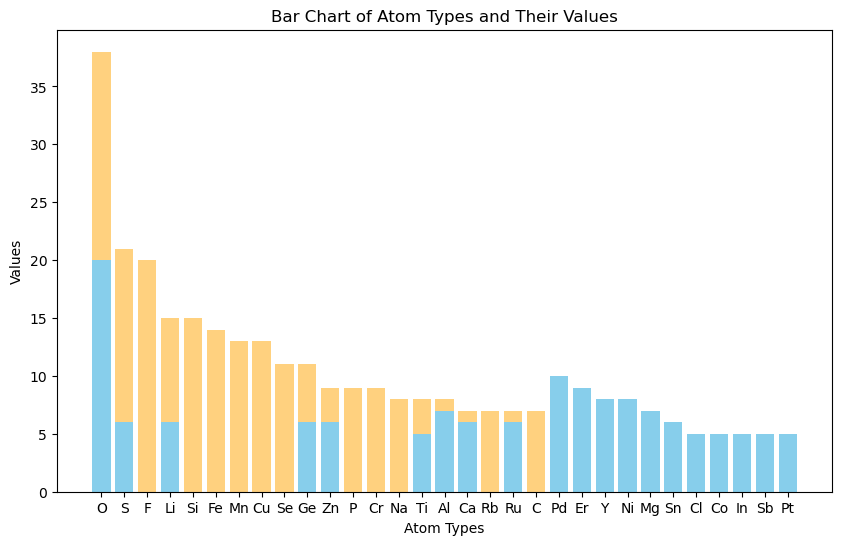

In [22]:
# Creating the bar chart
plt.figure(figsize=(10,6))
plt.bar(corr_atoms, corr_values, color='orange', alpha = 0.5)

plt.bar(miss_atoms, miss_values, color='skyblue')

plt.xlabel('Atom Types')
plt.ylabel('Values')
plt.title('Bar Chart of Atom Types and Their Values')
plt.show()

In [23]:
#if we exclude oxygen, sulfure and fluorine, what's the number of misclassified compounds? 
gt_formulas = list(misclassified_compounds['gt_formula'])
gt_elements = [sorted(extract_elements(gt_formula)) for gt_formula in gt_formulas]
contains_a_non_metal__elements = np.mean([("O" in one_list or "F" in one_list or "S" in one_list) for one_list in gt_elements])
contains_a_non_metal__elements

0.45625

In [24]:
#if we exclude oxygen, sulfure and fluorine, what's the number of misclassified compounds? 
gt_formulas = list(correct_compounds['gt_formula'])
gt_elements = [sorted(extract_elements(gt_formula)) for gt_formula in gt_formulas]
contains_a_non_metal__elements = np.mean([("O" in one_list or "F" in one_list or "S" in one_list) for one_list in gt_elements])
contains_a_non_metal__elements

0.2708333333333333

~45% of the misclassified compounds contain O, S, or F, compared to just 27%  of compounds that don't contain those elements. 

In [25]:
(1-contains_a_non_metal__elements)*len(correct_compounds) / ((1-contains_a_non_metal__elements)*len(misclassified_compounds) + (1-contains_a_non_metal__elements)*len(correct_compounds))

0.37499999999999994

Not much change

This makes sense, the compounds with high levels of non-metals tend to be misclassified at a much higher rate. Does this mean that molecular crystals are misclassified at a higher rate? 

In [26]:
#first get the number of molecular crstyals in the incorreect compounds
Mol_crystals_in_gt_misclassified_formulas = np.mean([("(" in formula) for formula in list(misclassified_compounds['gt_formula'])])

In [27]:
print(Mol_crystals_in_gt_misclassified_formulas)

0.11875


In [28]:
Mol_crystals_in_gt_correct_formulas = np.mean([("(" in formula) for formula in list(correct_compounds['gt_formula'])])

In [29]:
print(Mol_crystals_in_gt_correct_formulas)

0.07291666666666667


There's more molecular crystals in the misclassified compounds

In [30]:
#if we exclude the molecular crystals...
(1-0.033)*len(correct_compounds) / ((1-0.123)*len(misclassified_compounds) + (1-0.033)*len(correct_compounds))

0.39816085643700244

Minimal change in overall classification percentage

In [31]:
print(misclassified_compounds['pred_structure'].iloc[0])

Full Formula (Ca4 Ti4 O12)
Reduced Formula: CaTiO3
abc   :   5.414600   5.468547   7.871466
angles:  90.507271  90.214775  89.854843
pbc   :       True       True       True
Sites (20)
  #  SP           a         b         c
---  ----  --------  --------  --------
  0  Ti    0.83474   0.694701  0.453726
  1  Ti    0.339504  0.201459  0.952101
  2  Ca    0.375688  0.688957  0.693508
  3  Ca    0.792562  0.184831  0.201466
  4  Ti    0.842698  0.699597  0.954113
  5  Ca    0.883758  0.206051  0.699538
  6  Ca    0.30042   0.708667  0.200197
  7  O     0.130533  0.496338  0.493879
  8  O     0.854197  0.617605  0.200768
  9  O     0.318007  0.115406  0.700977
 10  Ti    0.345733  0.198813  0.449296
 11  O     0.045572  0.992395  0.406602
 12  O     0.547515  0.899985  0.410934
 13  O     0.039907  0.992301  0.993053
 14  O     0.630104  0.405719  0.910972
 15  O     0.363691  0.278597  0.201646
 16  O     0.545943  0.901891  0.99167
 17  O     0.810286  0.781706  0.705102
 18  O     0.632

In [32]:
def extract_num_atoms(text):
    element_pattern = r'Sites \((\d*)'
    num_atoms = re.findall(element_pattern, text)

#     # Extracting elements, ignoring the counts
    num_atoms = int(num_atoms[0])
    return(num_atoms)

In [33]:
print(extract_num_atoms(misclassified_compounds['pred_structure'].iloc[0]))

20


In [34]:
misclassified_compounds['num_atoms'] = misclassified_compounds['pred_structure'].apply(extract_num_atoms)

In [35]:
np.mean(misclassified_compounds['num_atoms'])

11.69375

In [36]:
correct_compounds['num_atoms'] = correct_compounds['pred_structure'].apply(extract_num_atoms)
np.mean(correct_compounds['num_atoms'])

8.822916666666666

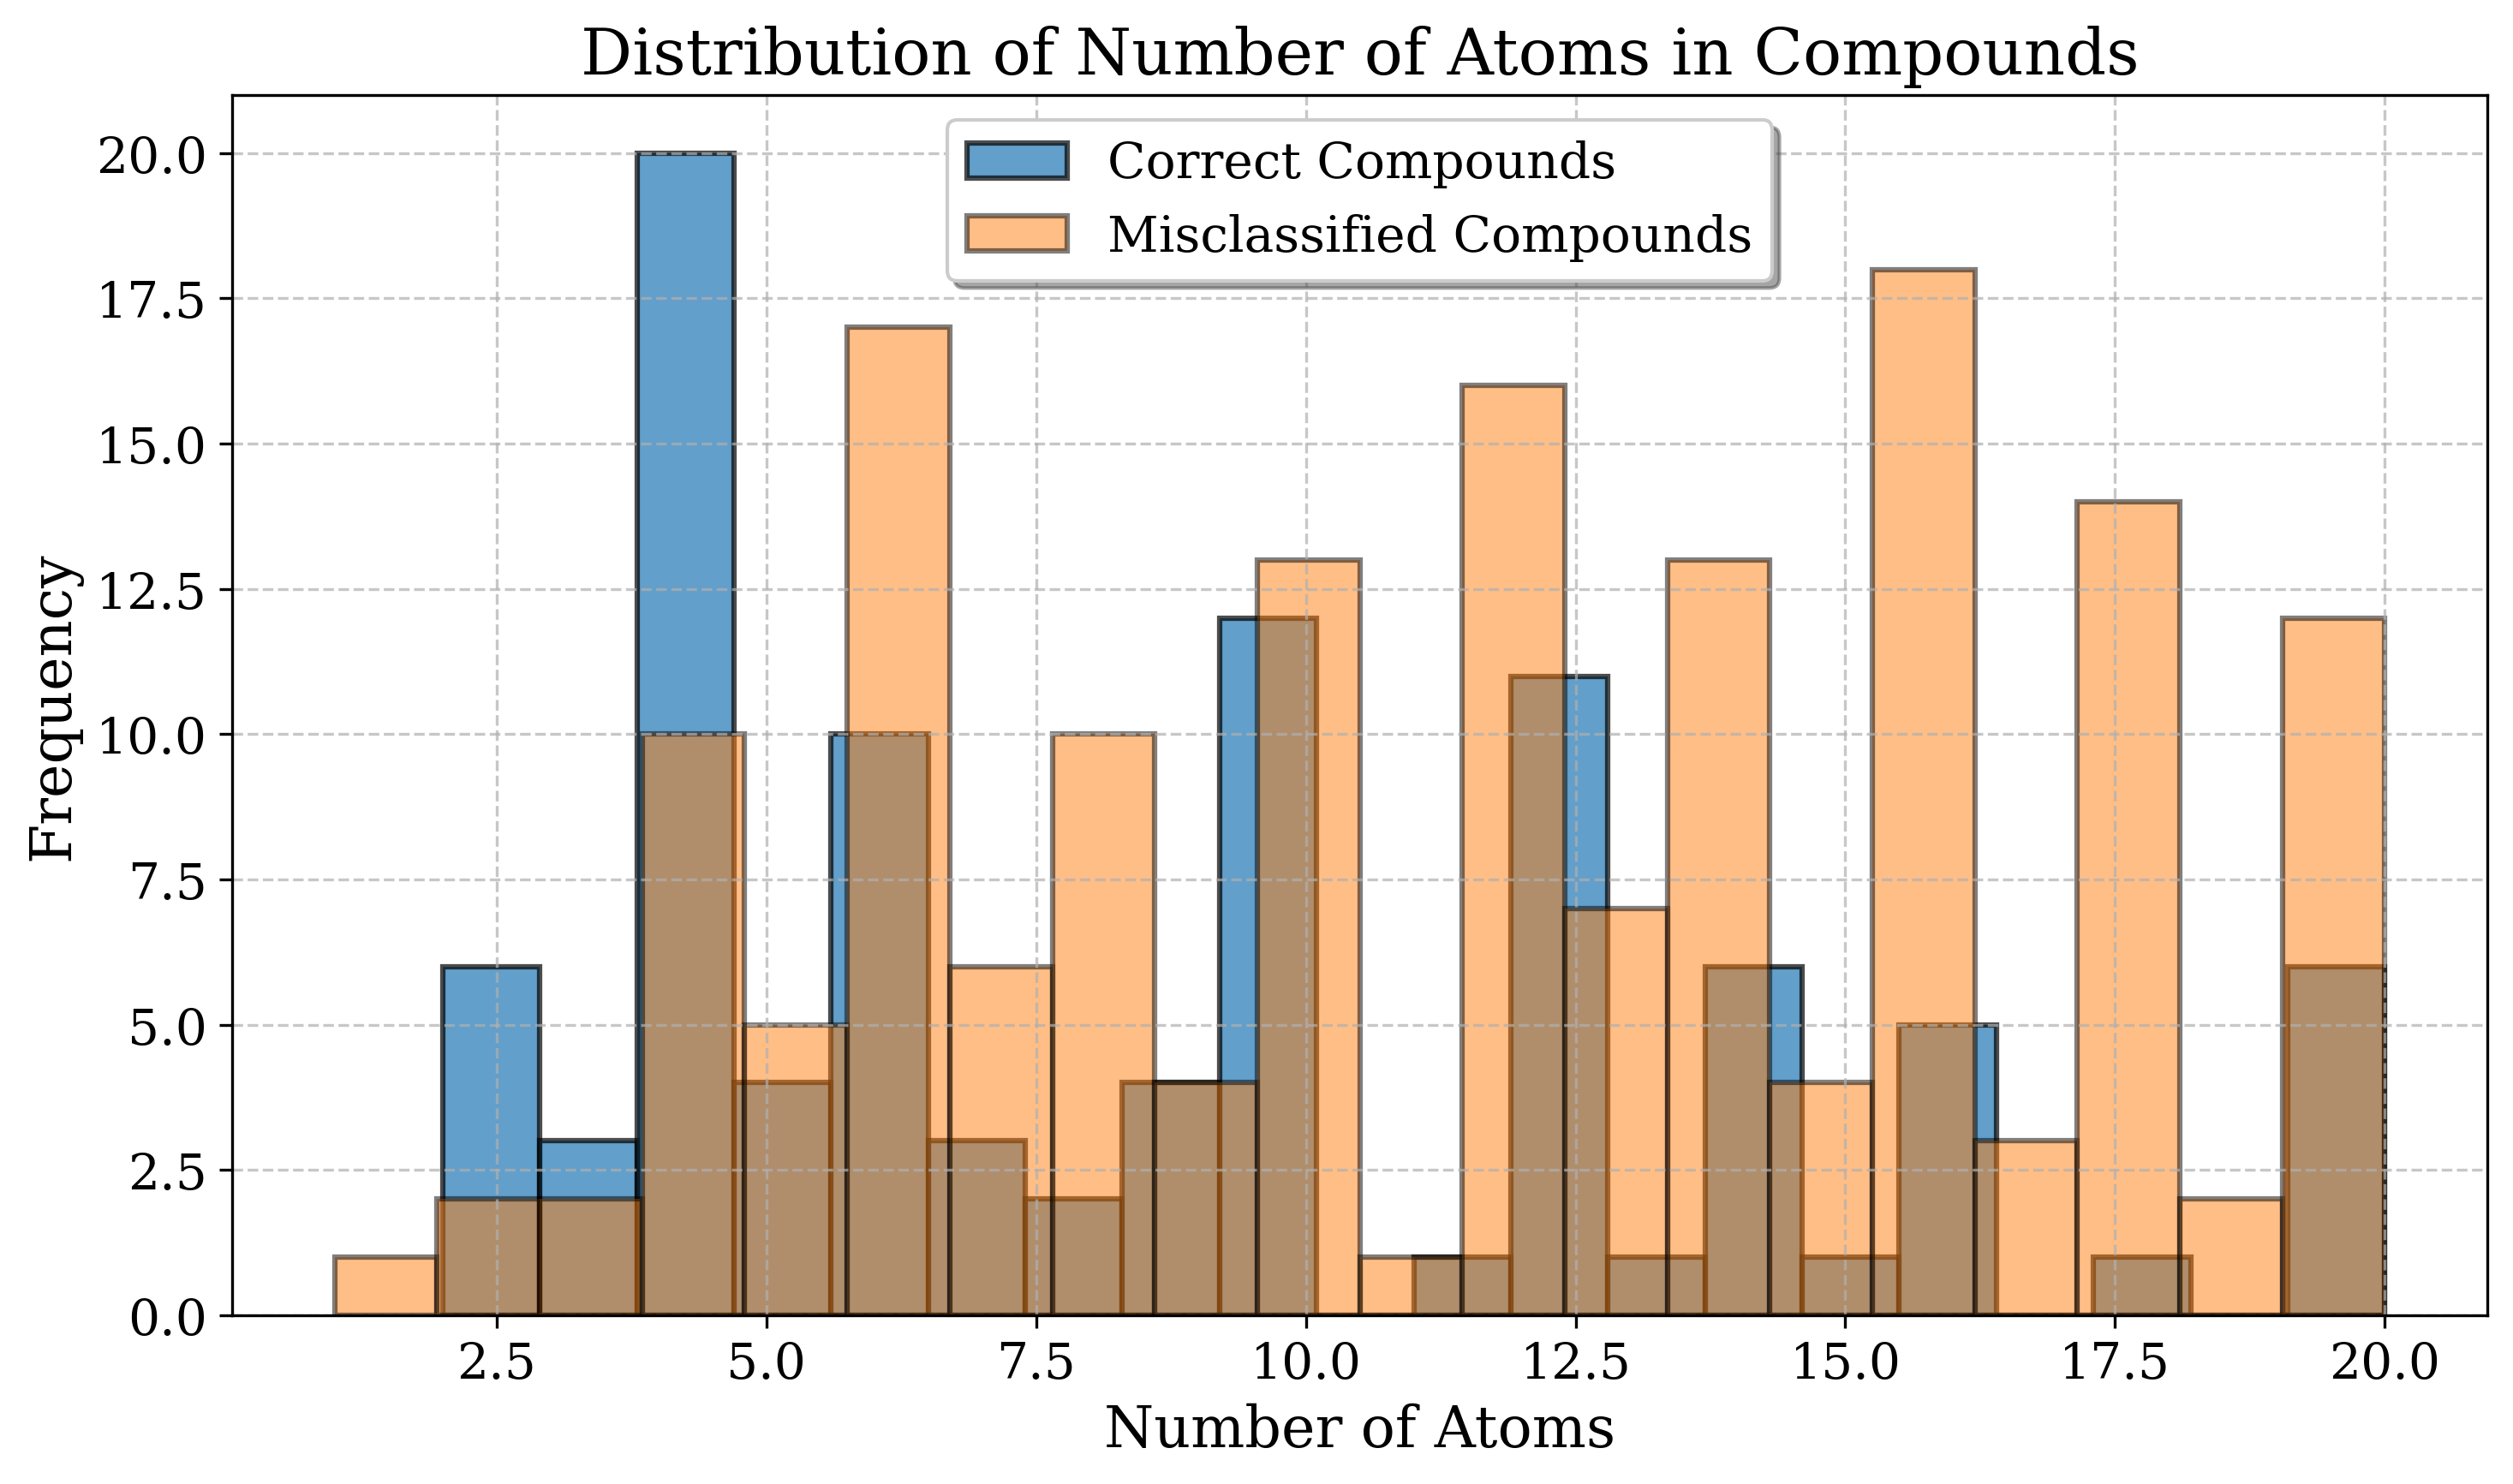

In [37]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Sample data (replace this with actual data)
# Assuming 'correct_compounds' and 'misclassified_compounds' are your dataframes

# Matplotlib settings for a publication-style figure
plt.figure(figsize=(10, 6), dpi=300)  # Increased resolution

# Font settings
plt.rcParams.update({'font.size': 14, 'font.family': 'serif'})

# Creating the histogram with labels
plt.hist(correct_compounds['num_atoms'], bins=20, alpha=0.7, label='Correct Compounds', edgecolor='black', linewidth=1.5)
plt.hist(misclassified_compounds['num_atoms'], bins=20, alpha=0.5, label='Misclassified Compounds', edgecolor='black', linewidth=1.5)

# Labels and title with increased size
plt.xlabel('Number of Atoms', fontsize=16)
plt.ylabel('Frequency', fontsize=16)
plt.title('Distribution of Number of Atoms in Compounds', fontsize=18)

# Styling the legend
plt.legend(fontsize=14, frameon=True, shadow=True)

# Optional: Adding gridlines
plt.grid(True, linestyle='--', alpha=0.7)

# Show plot
plt.tight_layout()  # Adjusts the plot to fit into the figure area.
plt.show()

Conv model has improved performance on bigger atoms (as expected)

Finally, let's look at the space group. 

In [38]:
print(misclassified_compounds['pred_structure'].iloc[1])

Full Formula (Zn9 N11)
Reduced Formula: Zn9N11
abc   :   4.638604   6.144134   9.996255
angles:  85.641418  86.302635  84.811188
pbc   :       True       True       True
Sites (20)
  #  SP           a         b         c
---  ----  --------  --------  --------
  0  Zn    0.523906  0.357346  0.598033
  1  N     0.718866  0.856944  0.978718
  2  N     0.710778  0.859564  0.218129
  3  Zn    0.059609  0.623024  0.755764
  4  N     0.324798  0.356199  0.437568
  5  Zn    0.058454  0.102762  0.436912
  6  Zn    0.062176  0.104346  0.75507
  7  Zn    0.594378  0.357943  0.268568
  8  Zn    0.029281  0.613469  0.442761
  9  Zn    0.144715  0.611552  0.096019
 10  Zn    0.600225  0.360639  0.926179
 11  N     0.842382  0.641514  0.26709
 12  Zn    0.139926  0.113567  0.096624
 13  N     0.348406  0.359479  0.098124
 14  N     0.477411  0.856658  0.09512
 15  N     0.839106  0.073603  0.267294
 16  N     0.839791  0.651601  0.92733
 17  N     0.324494  0.361596  0.753615
 18  N     0.058606  0.

In [39]:
print(misclassified_compounds['pred_structure'].iloc[0])

Full Formula (Ca4 Ti4 O12)
Reduced Formula: CaTiO3
abc   :   5.414600   5.468547   7.871466
angles:  90.507271  90.214775  89.854843
pbc   :       True       True       True
Sites (20)
  #  SP           a         b         c
---  ----  --------  --------  --------
  0  Ti    0.83474   0.694701  0.453726
  1  Ti    0.339504  0.201459  0.952101
  2  Ca    0.375688  0.688957  0.693508
  3  Ca    0.792562  0.184831  0.201466
  4  Ti    0.842698  0.699597  0.954113
  5  Ca    0.883758  0.206051  0.699538
  6  Ca    0.30042   0.708667  0.200197
  7  O     0.130533  0.496338  0.493879
  8  O     0.854197  0.617605  0.200768
  9  O     0.318007  0.115406  0.700977
 10  Ti    0.345733  0.198813  0.449296
 11  O     0.045572  0.992395  0.406602
 12  O     0.547515  0.899985  0.410934
 13  O     0.039907  0.992301  0.993053
 14  O     0.630104  0.405719  0.910972
 15  O     0.363691  0.278597  0.201646
 16  O     0.545943  0.901891  0.99167
 17  O     0.810286  0.781706  0.705102
 18  O     0.632

In [40]:
from pymatgen.core import Structure

In [41]:
misclassified_compounds['pred_structure']

2      Full Formula (Ca4 Ti4 O12)\nReduced Formula: C...
3      Full Formula (Zn9 N11)\nReduced Formula: Zn9N1...
7      Full Formula (Li6 S4)\nReduced Formula: Li3S2\...
8      Full Formula (Pm1 Mg1)\nReduced Formula: PmMg\...
9      Full Formula (Ca10 Pt6)\nReduced Formula: Ca5P...
                             ...                        
248    Full Formula (Fe4 S4)\nReduced Formula: FeS\na...
249    Full Formula (Li1 U3 N1)\nReduced Formula: LiU...
250    Full Formula (Nb5 Cl6 O9)\nReduced Formula: Nb...
252    Full Formula (V5 S14)\nReduced Formula: V5S14\...
253    Full Formula (Cr5 Ag5 S10)\nReduced Formula: C...
Name: pred_structure, Length: 160, dtype: object

In [42]:
from pymatgen.core.structure import Structure
from pymatgen.symmetry.analyzer import SpacegroupAnalyzer

In [43]:
from pymatgen.core.structure import Structure
from pymatgen.core.lattice import Lattice
import re

def extract_and_create_structure(data_str, tol = 0.01):
    # Extract lattice parameters and angles
    lattice_params = re.findall(r"abc\s+:\s+([\d.]+)\s+([\d.]+)\s+([\d.]+)", data_str)[0]
    angles = re.findall(r"angles:\s+([\d.]+)\s+([\d.]+)\s+([\d.]+)", data_str)[0]

    # Convert to float
    lattice_params = [float(param) for param in lattice_params]
    angles = [float(angle) for angle in angles]

    # Create Lattice object
    lattice = Lattice.from_parameters(*lattice_params, *angles)

    # Extract atom positions
    atom_lines = re.findall(r"(\d+)\s+(\w+)\s+([\d.]+)\s+([\d.]+)\s+([\d.]+)", data_str)
    species = [line[1] for line in atom_lines]
    coords = [[float(line[2]), float(line[3]), float(line[4])] for line in atom_lines]

    # Create Structure object
    structure = Structure(lattice, species, coords)
        
    # Create a SpacegroupAnalyzer object
    spacegroup_analyzer = SpacegroupAnalyzer(structure, symprec=tol)

    # Get the space group
    space_group = spacegroup_analyzer.get_space_group_number()

    return space_group

(array([ 8.,  3., 13.,  2.,  0.,  7., 11.,  5.,  9., 38.]),
 array([  2. ,  24.5,  47. ,  69.5,  92. , 114.5, 137. , 159.5, 182. ,
        204.5, 227. ]),
 <BarContainer object of 10 artists>)

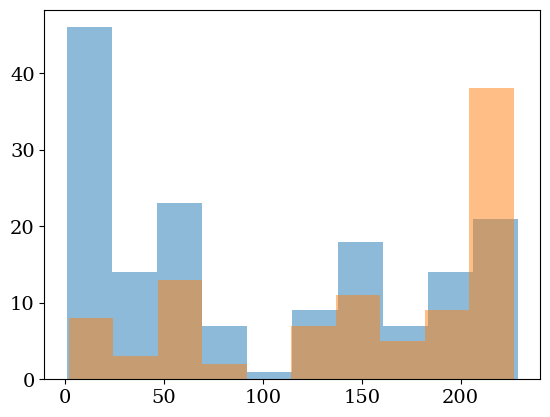

In [44]:
misclassified_compounds['gt_sg'] = misclassified_compounds['gt_structure'].apply(
    lambda x: extract_and_create_structure(x, tol = 0.01))

import matplotlib.pyplot as plt

plt.hist(misclassified_compounds['gt_sg'], alpha = 0.5) # blue is gt 

correct_compounds['gt_sg'] = correct_compounds['gt_structure'].apply(
    lambda x: extract_and_create_structure(x, tol = 0.01))
# boosted the tolerance way up to account for minor differences in frac coords 
# stuff like that


plt.hist(correct_compounds['gt_sg'], alpha = 0.5) # orange is pred

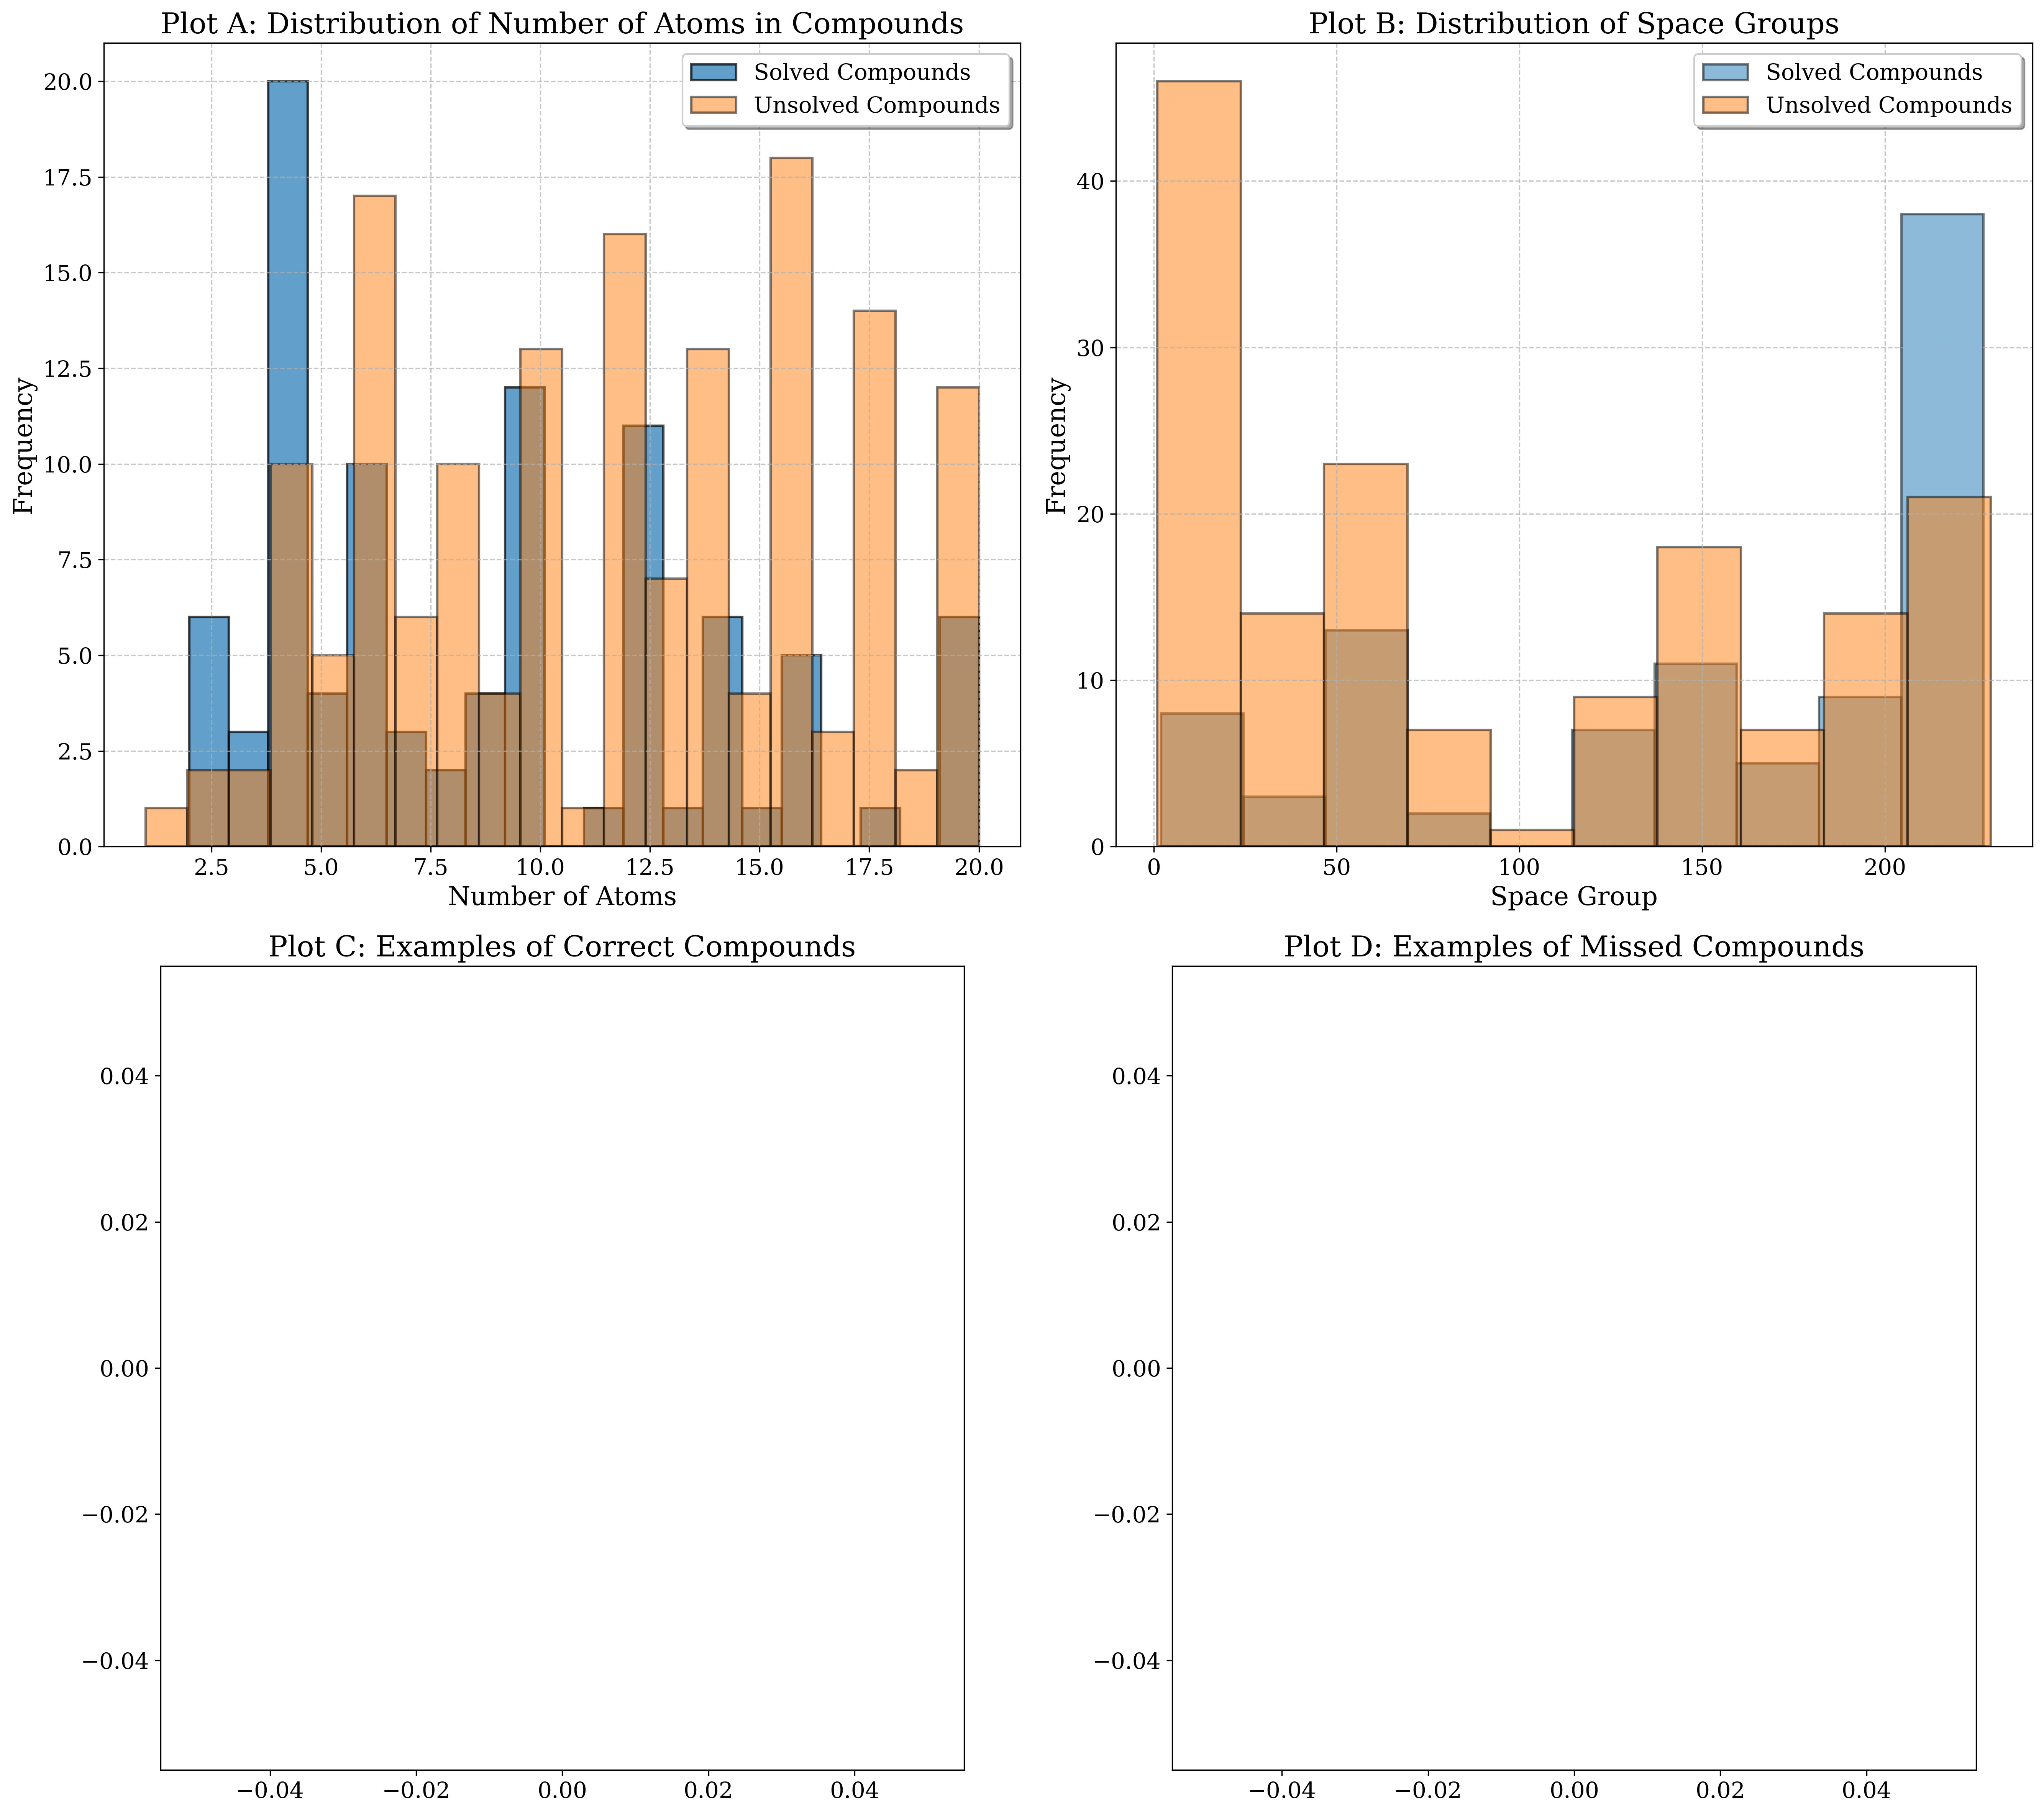

In [96]:
import matplotlib.pyplot as plt
import pandas as pd

# Create a figure with four subplots (2x2 grid)
plt.figure(figsize=(18, 16), dpi=300)  # Adjusted size for 2x2 grid

# Plot A
plt.subplot(2, 2, 1)  # 2 rows, 2 columns, first plot
plt.hist(correct_compounds['num_atoms'], bins=20, alpha=0.7, label='Solved Compounds', edgecolor='black', linewidth=1.5)
plt.hist(misclassified_compounds['num_atoms'], bins=20, alpha=0.5, label='Unsolved Compounds', edgecolor='black', linewidth=1.5)
plt.xlabel('Number of Atoms', fontsize=16)
plt.ylabel('Frequency', fontsize=16)
plt.title('Plot A: Distribution of Number of Atoms in Compounds', fontsize=18)
plt.legend(fontsize=14, frameon=True, shadow=True)
plt.grid(True, linestyle='--', alpha=0.7)

# Plot B
plt.subplot(2, 2, 2)  # 2 rows, 2 columns, second plot
plt.hist(correct_compounds['gt_sg'], alpha=0.5, label='Solved Compounds', edgecolor='black', linewidth=1.5)
plt.hist(misclassified_compounds['gt_sg'], alpha=0.5, label='Unsolved Compounds', edgecolor='black', linewidth=1.5)
plt.xlabel('Space Group', fontsize=16)
plt.ylabel('Frequency', fontsize=16)
plt.title('Plot B: Distribution of Space Groups', fontsize=18)
plt.legend(fontsize=14, frameon=True, shadow=True)
plt.grid(True, linestyle='--', alpha=0.7)

# Plot C (Empty)
plt.subplot(2, 2, 3)  # 2 rows, 2 columns, third plot
plt.axis('square')  # Makes the plot square shaped
plt.title('Plot C: Examples of Correct Compounds', fontsize=18)

# Plot D (Empty)
plt.subplot(2, 2, 4)  # 2 rows, 2 columns, fourth plot
plt.axis('square')  # Makes the plot square shaped
plt.title('Plot D: Examples of Missed Compounds', fontsize=18)

# Adjust overall layout
plt.tight_layout()
plt.savefig('/home/gridsan/tmackey/cdvae/scripts/1-05-2024_experimental_data/fig_4.png')

Let's look at the correctly classified compounds now 

(array([27.,  1., 10.,  2.,  0.,  3.,  5.,  6.,  7., 35.]),
 array([  2. ,  24.5,  47. ,  69.5,  92. , 114.5, 137. , 159.5, 182. ,
        204.5, 227. ]),
 <BarContainer object of 10 artists>)

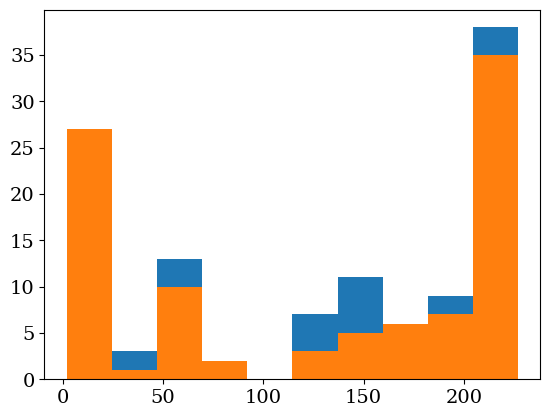

In [46]:
correct_compounds['gt_sg'] = correct_compounds['gt_structure'].apply(
    lambda x: extract_and_create_structure(x, tol = 0.01))

import matplotlib.pyplot as plt

plt.hist(correct_compounds['gt_sg']) # blue is gt 

correct_compounds['pred_sg'] = correct_compounds['pred_structure'].apply(
    lambda x: extract_and_create_structure(x, tol = 0.5))
# boosted the tolerance way up to account for minor differences in frac coords 
# stuff like that


plt.hist(correct_compounds['pred_sg']) # orange is pred

Note that this shows that a compound can be classified as correct even if there are small changes in the structure that lead it to be lower symmetry

NEXT QUESTION: THE WHY 

For a compound to get correctly classified, there are some things that the most must get right. First is the number of atoms. Second is the stoichiometry. We give it the number of atoms so that's not important. What percentage of the misclassified compounds have incorrect stoich?

In [47]:
incorrect_stoich = results_df[results_df['pred_formula'] != results_df['gt_formula']].copy()

In [70]:
pd.set_option('display.max_rows', 10000)  # Replace None with a large number if needed
pd.set_option('display.max_columns', 10000)  # Replace None with a large number if needed

In [71]:
incorrect_stoich

,Unnamed: 0,pred_formula,gt_formula,pred_structure,gt_structure,rmsd
2,2,CaTiO3,NaCaTaTiO6,Full Formula (Ca4 Ti4 O12)\nReduced Formula: C...,Full Formula (Na2 Ca2 Ta2 Ti2 O12)\nReduced Fo...,NaN
3,3,Zn9N11,Zn3N2,Full Formula (Zn9 N11)\nReduced Formula: Zn9N1...,Full Formula (Zn12 N8)\nReduced Formula: Zn3N2...,NaN
7,7,Li3S2,LiS4,Full Formula (Li6 S4)\nReduced Formula: Li3S2\...,Full Formula (Li2 S8)\nReduced Formula: LiS4\n...,NaN
16,16,KBi2I7,Cs2KBiI6,Full Formula (K1 Bi2 I7)\nReduced Formula: KBi...,Full Formula (Cs2 K1 Bi1 I6)\nReduced Formula:...,NaN
18,18,Ho4Cu7P5,Ho4Cu5P7,Full Formula (Ho4 Cu7 P5)\nReduced Formula: Ho...,Full Formula (Ho4 Cu5 P7)\nReduced Formula: Ho...,NaN
19,19,DyRu3,DyTmRu2,Full Formula (Dy1 Ru3)\nReduced Formula: DyRu3...,Full Formula (Dy1 Tm1 Ru2)\nReduced Formula: D...,NaN
21,21,Ti2GaC,Ti4GaC3,Full Formula (Ti8 Ga4 C4)\nReduced Formula: Ti...,Full Formula (Ti8 Ga2 C6)\nReduced Formula: Ti...,NaN
22,22,DyFe2,DyMnFe,Full Formula (Dy2 Fe4)\nReduced Formula: DyFe2...,Full Formula (Dy2 Mn2 Fe2)\nReduced Formula: D...,NaN
24,24,SrLa2Co3O8,SrLaCoO4,Full Formula (Sr1 La2 Co3 O8)\nReduced Formula...,Full Formula (Sr2 La2 Co2 O8)\nReduced Formula...,NaN
27,27,V6O11F,V3O5F,Full Formula (V6 O11 F1)\nReduced Formula: V6O...,Full Formula (V6 O10 F2)\nReduced Formula: V3O...,NaN


Looks like around 80% of the incorrectly classified compounds have incorrect stoichiometry assignments, making the assignment of structure basically impossible. *The model is significatly limited by its curent ability to predict stoichiometry* 

In [72]:
len(incorrect_stoich) / len(results_df)

0.4296875

In [66]:
rmd = np.array(results_df['rmsd'])

In [69]:
len(element_equality)

110

So it looks like only 66% of the incorrectly classified compounds even have all the elements in them. This is actually suprisingly low

In [56]:
element_equality 

array([False,  True,  True, False,  True, False,  True, False,  True,
        True,  True,  True, False,  True,  True, False,  True,  True,
        True,  True, False,  True,  True,  True, False,  True,  True,
       False,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True, False, False,  True, False,  True, False, False,
        True,  True, False, False,  True,  True,  True, False, False,
       False,  True,  True,  True, False, False, False,  True, False,
        True,  True,  True,  True, False,  True, False,  True,  True,
        True, False, False,  True,  True, False,  True,  True,  True,
        True,  True,  True, False, False,  True,  True,  True,  True,
        True, False,  True,  True,  True,  True,  True, False,  True,
        True,  True,  True, False,  True, False, False,  True,  True,
       False, False])

In [63]:
index = 7

In [64]:
pred_elements[index]

['Dy', 'Fe']

In [65]:
gt_elements[index]

['Dy', 'Fe', 'Mn']

In addition to the one-shot results, arguable the more interesting results come from the multi-shot "experiments"

In [1]:
from collections import Counter
import argparse
import os
import json

import numpy as np
import torch

In [2]:
from eval_utils import (
    smact_validity, structure_validity, CompScaler, get_fp_pdist,
    load_config, load_data, get_crystals_list, prop_model_eval, compute_cov)


In [4]:
model_path = '/home/gridsan/tmackey/hydra/singlerun/2024-01-05/mp_20_pv'

In [5]:
def get_file_paths(root_path, task, label='', suffix='pt'):
    if label == '':
        out_name = f'eval_{task}.{suffix}'
    else:
        out_name = f'eval_{task}_{label}.{suffix}'
    out_name = os.path.join(root_path, out_name)
    return out_name

recon_file_path = get_file_paths(model_path, 'recon',label='mp_20')

# def get_crystal_array_list(file_path, batch_idx=0):
file_path = recon_file_path
data = load_data(file_path)

In [6]:
data

{'eval_setting': Namespace(batch_size=500, disable_bar=False, down_sample_traj_step=10, force_atom_types=False, force_num_atoms=True, label='mp_20', min_sigma=0, model_path='/home/gridsan/tmackey/hydra/singlerun/2024-01-05/mp_20_pv', n_step_each=100, num_batches=1, num_batches_to_samples=20, num_evals=64, save_traj=True, start_from='data', step_lr=0.0001, tasks=['recon'], test_set_override='mp_20'),
 'input_data_batch': Batch(edge_index=[2, 20512], y=[256, 1], frac_coords=[2718, 3], atom_types=[2718], lengths=[256, 3], angles=[256, 3], to_jimages=[20512, 3], num_atoms=[256], num_bonds=[256], num_nodes=2718, batch=[2718], ptr=[257]),
 'frac_coords': tensor([[[0.4826, 0.4761, 0.3248],
          [0.9860, 0.9684, 0.8267],
          [0.2318, 0.2194, 0.0842],
          ...,
          [0.5419, 0.1330, 0.7279],
          [0.9848, 0.1350, 0.2887],
          [0.5463, 0.5689, 0.7286]],
 
         [[0.6138, 0.6444, 0.7919],
          [0.1091, 0.1456, 0.3009],
          [0.8684, 0.8853, 0.0516],
  

In [ ]:
for eval_num in range(num_batches): 
    print("eval num is ", eval_num)
    crys_array_list, true_crystal_array_list = get_crystal_array_list(file_path, batch_idx=eval_num)

In [ ]:
__, true_crystal_array_list = get_crystal_array_list(file_path, batch_idx=0)

In [7]:
def get_crystals_list(
        frac_coords, atom_types, lengths, angles, num_atoms):
    """
    args:
        frac_coords: (num_atoms, 3)
        atom_types: (num_atoms)
        lengths: (num_crystals)
        angles: (num_crystals)
        num_atoms: (num_crystals)
    """
    assert frac_coords.size(0) == atom_types.size(0) == num_atoms.sum()
    assert lengths.size(0) == angles.size(0) == num_atoms.size(0)

    start_idx = 0
    crystal_array_list = []
    for batch_idx, num_atom in enumerate(num_atoms.tolist()):
        cur_frac_coords = frac_coords.narrow(0, start_idx, num_atom)
        cur_atom_types = atom_types.narrow(0, start_idx, num_atom)
        cur_lengths = lengths[batch_idx]
        cur_angles = angles[batch_idx]

        crystal_array_list.append({
            'frac_coords': cur_frac_coords.detach().cpu().numpy(),
            'atom_types': cur_atom_types.detach().cpu().numpy(),
            'lengths': cur_lengths.detach().cpu().numpy(),
            'angles': cur_angles.detach().cpu().numpy(),
        })
        start_idx = start_idx + num_atom
    return crystal_array_list

def get_crystal_array_list(file_path, batch_idx=0):
    data = load_data(file_path)
    crys_array_list = get_crystals_list(
        data['frac_coords'][batch_idx],
        data['atom_types'][batch_idx],
        data['lengths'][batch_idx],
        data['angles'][batch_idx],
        data['num_atoms'][batch_idx])

    if 'input_data_batch' in data:
        batch = data['input_data_batch']
        if isinstance(batch, dict):
            true_crystal_array_list = get_crystals_list(
                batch['frac_coords'], batch['atom_types'], batch['lengths'],
                batch['angles'], batch['num_atoms'])
        else:
            true_crystal_array_list = get_crystals_list(
                batch.frac_coords, batch.atom_types, batch.lengths,
                batch.angles, batch.num_atoms)
    else:
        true_crystal_array_list = None

    return crys_array_list, true_crystal_array_list

In [9]:
num_batches = 64

In [12]:
list_of_preds = []

In [13]:
for eval_num in range(num_batches): 
    print("eval num is ", eval_num)
    crys_array_list, true_crystal_array_list = get_crystal_array_list(file_path, batch_idx=eval_num)
    list_of_preds.append(crys_array_list)

eval num is  0
eval num is  1
eval num is  2
eval num is  3
eval num is  4
eval num is  5
eval num is  6
eval num is  7
eval num is  8
eval num is  9
eval num is  10
eval num is  11
eval num is  12
eval num is  13
eval num is  14
eval num is  15
eval num is  16
eval num is  17
eval num is  18
eval num is  19
eval num is  20
eval num is  21
eval num is  22
eval num is  23
eval num is  24
eval num is  25
eval num is  26
eval num is  27
eval num is  28
eval num is  29
eval num is  30
eval num is  31
eval num is  32
eval num is  33
eval num is  34
eval num is  35
eval num is  36
eval num is  37
eval num is  38
eval num is  39
eval num is  40
eval num is  41
eval num is  42
eval num is  43
eval num is  44
eval num is  45
eval num is  46
eval num is  47
eval num is  48
eval num is  49
eval num is  50
eval num is  51
eval num is  52
eval num is  53
eval num is  54
eval num is  55
eval num is  56
eval num is  57
eval num is  58
eval num is  59
eval num is  60
eval num is  61
eval num is  62
ev

use the rmsd results

In [14]:
#results from the 64-shot 

results = np.array([5.18096925e-01, 6.43680706e-01, 6.13973317e-02, 1.91050386e-02,
       6.23723857e-01, 4.77996560e-01, 6.59923950e+00, 0.00000000e+00,
       0.00000000e+00, 8.81484147e-01, 8.84493149e-01, 1.48820926e+00,
       5.24027371e-01, 2.59492708e+00, 5.39708779e-01, 3.21021969e+00,
       4.64958265e-01, 0.00000000e+00, 0.00000000e+00, 3.43359786e-01,
       5.74236177e+00, 0.00000000e+00, 8.61916524e-03, 5.95346125e-01,
       0.00000000e+00, 4.22314736e-01, 4.89577133e-01, 1.16074092e-01,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 4.83101574e-01,
       0.00000000e+00, 9.57420876e-01, 5.52135367e-01, 1.99209998e+00,
       8.80301735e-01, 2.84180684e+00, 5.44289824e-01, 5.00891633e-01,
       4.52214337e-01, 2.77061106e+00, 5.43778900e-01, 0.00000000e+00,
       4.56116973e-01, 4.64465300e-01, 5.02399466e-01, 1.28511859e+01,
       1.92300660e+00, 0.00000000e+00, 3.32352523e-01, 2.04198967e+00,
       5.84309496e-01, 0.00000000e+00, 1.26798699e+00, 8.68216471e-01,
       1.18111354e+00, 4.80754386e-01, 6.12136423e-01, 5.72154544e-01,
       0.00000000e+00, 0.00000000e+00, 1.92543174e+00, 3.92141828e-01,
       3.75803362e+00, 5.81629514e+00, 0.00000000e+00, 0.00000000e+00,
       8.14148183e-03, 1.57746314e+00, 0.00000000e+00, 9.70707724e-01,
       0.00000000e+00, 0.00000000e+00, 1.07531613e+01, 1.10443331e+00,
       3.69175752e-01, 3.38727371e+00, 1.60675476e-01, 0.00000000e+00,
       1.09537693e+00, 7.10524842e-01, 6.55027375e-01, 2.26843530e+00,
       4.25029593e-01, 2.70003830e-02, 1.59261943e-02, 8.44365618e+00,
       0.00000000e+00, 1.87076208e+00, 4.85705196e-01, 3.78634554e-01,
       1.65098343e-01, 0.00000000e+00, 0.00000000e+00, 7.71284586e-01,
       1.81541026e+00, 1.32558332e+01, 4.45564550e+00, 2.83902435e+00,
       5.71106686e-01, 3.13862900e-01, 3.43103395e-02, 9.69043849e-01,
       1.11489694e+00, 0.00000000e+00, 2.32761738e-01, 7.58643750e-01,
       0.00000000e+00, 5.93616954e+00, 4.57883985e+00, 1.90874273e-01,
       8.55345824e-01, 6.07589280e-01, 6.31235632e-02, 6.39047128e-01,
       3.18354451e-01, 6.27683800e-01, 1.03693555e+01, 6.71558887e-01,
       1.32505220e+00, 1.56028286e+00, 0.00000000e+00, 4.60991807e-01,
       1.88685901e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       7.68374190e-01, 0.00000000e+00, 0.00000000e+00, 6.19298645e-01,
       1.21509238e+00, 0.00000000e+00, 5.05779951e-01, 1.26689115e+00,
       7.49794656e-01, 0.00000000e+00, 4.97747073e-01, 6.32310466e-01,
       7.04521198e-01, 1.16156758e+00, 1.13151700e+00, 6.81181621e-01,
       3.50795326e-01, 2.18777108e-01, 1.94118908e+00, 1.31279646e+00,
       4.13396118e-02, 5.82591796e-01, 0.00000000e+00, 8.90701308e-01,
       4.52745489e-01, 6.03781323e-01, 0.00000000e+00, 4.86215916e-01,
       3.78878584e+00, 7.31753294e-01, 8.78225995e-01, 0.00000000e+00,
       1.12613540e+00, 6.96146149e-01, 0.00000000e+00, 3.88120391e-02,
       5.31105710e-01, 0.00000000e+00, 3.68824591e-01, 1.27418619e+00,
       1.20227525e-01, 2.51048798e+00, 4.19512107e-01, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 4.77199774e-02,
       0.00000000e+00, 4.10652978e-01, 2.11376608e+00, 9.68197106e-01,
       0.00000000e+00, 5.56373245e-01, 2.64974480e+00, 1.17001342e-01,
       2.67892303e-01, 4.79855315e+00, 0.00000000e+00, 0.00000000e+00,
       1.96691597e+00, 1.32392525e+00, 2.54870381e+00, 1.18505058e+00,
       1.30674205e+00, 3.68751407e-01, 0.00000000e+00, 0.00000000e+00,
       6.18006700e+00, 1.17375167e+00, 4.98949545e-01, 6.08173381e-02,
       4.03405909e-01, 3.53273159e-01, 8.35727820e+00, 5.85473622e-01,
       4.98855426e-01, 8.12410454e-01, 1.64254201e-01, 0.00000000e+00,
       1.72398735e-01, 4.93976483e-01, 0.00000000e+00, 1.33257040e+00,
       0.00000000e+00, 3.14379017e-01, 6.51848721e-01, 3.66270809e+00,
       9.68706903e+00, 1.74345023e+00, 2.54015667e-02, 0.00000000e+00,
       0.00000000e+00, 5.63093488e-01, 2.97918380e-01, 7.49656665e-02,
       1.49511982e+00, 0.00000000e+00, 5.24384644e+00, 0.00000000e+00,
       4.50100048e+00, 9.38404391e-01, 0.00000000e+00, 6.42108931e-01,
       0.00000000e+00, 0.00000000e+00, 6.84379816e+00, 1.24818779e+00,
       6.15628005e-01, 1.40337373e+00, 5.19304050e-01, 3.04372326e+00,
       0.00000000e+00, 0.00000000e+00, 4.60197760e-01, 2.38064609e+00,
       3.97237575e-01, 9.96620887e+00, 8.50377018e-01, 5.65521008e-01,
       3.82100410e-02, 5.12850881e+00, 0.00000000e+00, 8.07075820e-01,
       0.00000000e+00, 0.00000000e+00, 1.47033547e-01, 1.70407329e+00])

We want to figure out what % of the misclassified compounds never "got" the right stoichiometry.

In [19]:
incorrectly_classified = [crystal for index, crystal in enumerate(true_crystal_array_list) if results[index] == 0]

In [28]:
correctly_classified = [crystal for index, crystal in enumerate(true_crystal_array_list) if results[index] > 0]

In [44]:
len(list_of_preds[0])

256

In [45]:
correspondingpred = []
for uindex in range(64): 
    sublist = [crystal for index, crystal in enumerate(list_of_preds[uindex]) if results[index] == 0]
    correspondingpred.append(sublist)

In [46]:
len(correspondingpred)

64

In [47]:
correspondingpred[index][uindex]

{'frac_coords': array([[0.91897494, 0.6204588 , 0.7157811 ],
        [0.7211083 , 0.71784675, 0.31604865],
        [0.5244561 , 0.32153925, 0.91333103],
        [0.7216061 , 0.22247054, 0.314308  ],
        [0.11527601, 0.5222576 , 0.11671898],
        [0.5248933 , 0.81647605, 0.91119593],
        [0.92538077, 0.11885192, 0.7139673 ],
        [0.32583752, 0.41897866, 0.51303893],
        [0.61902964, 0.73273975, 0.6405955 ],
        [0.02996943, 0.11395852, 0.38456663],
        [0.82480407, 0.7075544 , 0.9868411 ],
        [0.21682774, 0.9309262 , 0.8420965 ],
        [0.32550567, 0.9219139 , 0.51428914],
        [0.01905766, 0.529962  , 0.44170445],
        [0.41057307, 0.32712066, 0.23860048],
        [0.43182683, 0.9139735 , 0.18721183],
        [0.8143132 , 0.13077928, 0.0376263 ],
        [0.11742048, 0.02158183, 0.11311856],
        [0.22671326, 0.51204675, 0.7894623 ],
        [0.6286349 , 0.3102126 , 0.58970946]], dtype=float32),
 'atom_types': array([24, 47, 47, 24, 47, 24, 47

In [71]:
from collections import Counter

In [74]:
counter = 0 
for uindex in range(64): 
    for index in range(64): 
        if Counter(incorrectly_classified[uindex]['atom_types']) == Counter(correspondingpred[index][uindex]['atom_types']):
            counter += 1
            break 

In [75]:
counter

52

This means that out of the incorrectly classified compounds, with 64 samples, the correct stoichiometry is attemped in a solid 52 of 64.

In [76]:
counter = 0 
for uindex in range(64): 
    for index in range(64): 
        if Counter(incorrectly_classified[uindex]['atom_types']) == Counter(correspondingpred[index][uindex]['atom_types']):
            counter += 1
            

In [79]:
counter / 64

19.390625

On average, each compound got 19 "shots" with a correct stoichiometry 

However, it does look like the majority of them are getting all of the right elements in, which is good. 

In [68]:
def count_elements(lst):
    element_count = {}
    for element in lst:
        if element in element_count:
            element_count[element] += 1
        else:
            element_count[element] = 1
    return element_count


In [70]:
counter = 0 
for uindex in range(64): 
    print("correct types: ", count_elements(incorrectly_classified[uindex]['atom_types']))
    counter_before = counter 
    for index in range(64): 
        if tuple(incorrectly_classified[uindex]['atom_types']) == tuple(correspondingpred[index][uindex]['atom_types']):
            #print("at least one match")
            counter += 1
            break
    if counter_before == counter: 
        for index in range(64): 
            print(count_elements(correspondingpred[index][uindex]['atom_types']))

correct types:  {3: 2, 16: 8}
{3: 6, 16: 4}
{3: 5, 16: 5}
{16: 10}
{3: 5, 16: 5}
{3: 5, 16: 5}
{3: 5, 16: 5}
{3: 6, 16: 4}
{16: 10}
{3: 6, 16: 4}
{3: 6, 16: 4}
{3: 6, 16: 4}
{3: 5, 16: 5}
{16: 4, 3: 6}
{3: 6, 16: 4}
{16: 5, 3: 5}
{3: 6, 16: 4}
{3: 5, 16: 5}
{3: 6, 16: 4}
{3: 6, 16: 4}
{3: 5, 16: 5}
{3: 5, 16: 5}
{3: 6, 16: 4}
{3: 5, 16: 5}
{3: 5, 16: 5}
{16: 10}
{3: 6, 16: 4}
{3: 6, 16: 4}
{3: 6, 16: 4}
{3: 6, 16: 4}
{3: 4, 16: 6}
{16: 5, 3: 5}
{3: 5, 16: 5}
{3: 4, 16: 6}
{3: 5, 16: 5}
{3: 5, 16: 5}
{3: 5, 16: 5}
{3: 6, 16: 4}
{3: 6, 16: 4}
{3: 6, 16: 4}
{3: 5, 16: 5}
{3: 6, 16: 4}
{16: 4, 3: 6}
{3: 6, 16: 4}
{16: 4, 3: 6}
{16: 8, 3: 2}
{3: 5, 16: 5}
{16: 4, 3: 6}
{3: 6, 16: 4}
{3: 5, 16: 5}
{3: 6, 16: 4}
{3: 6, 16: 4}
{3: 6, 16: 4}
{3: 5, 16: 5}
{3: 6, 16: 4}
{16: 6, 3: 4}
{3: 6, 16: 4}
{3: 6, 16: 4}
{16: 5, 3: 5}
{3: 5, 16: 5}
{3: 6, 16: 4}
{3: 6, 16: 4}
{3: 5, 16: 5}
{3: 6, 16: 4}
{3: 6, 16: 4}
correct types:  {61: 1, 12: 1}
correct types:  {66: 2, 30: 1, 29: 1, 14: 2}
correct types

Finally, out of an abundance of caution, let's make sure that there is no overlap between the training and the testing set.

In [1]:
import pandas as pd 
import numpy as np 


In [9]:
train_df = pd.read_csv("/home/gridsan/tmackey/cdvae/data/mp_20/old_as_of_01_06/train.csv")

In [10]:
test_df = pd.read_csv("/home/gridsan/tmackey/cdvae/data/mp_20/old_as_of_01_06/test.csv")

In [11]:
test_df

,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0,material_id,formation_energy_per_atom,band_gap,pretty_formula,e_above_hull,elements,cif,spacegroup.number,xrd,xrd_peak_locations,xrd_peak_intensities,atomic_numbers,TsachID,disc_sim_xrd,lattice_system,lattice parameters
0,0,0,65,mp-865981,-0.436368,0.0000,TmMgHg2,0.000000,"['Hg', 'Mg', 'Tm']",# generated using pymatgen\ndata_TmMgHg2\n_sym...,225,DiffractionPattern\n$2\Theta$: [21.55678075 24...,"[21.556780747105403, 24.941537504017845, 35.56...","[13.285961903680525, 14.591926184240076, 100.0...","[69, 12, 80, 80]",TmMgHgHg5.04880045.04880045.048800460.060.060.0,[ 0. 0. 0. 0. ...,4.0,"[5.0488004, 5.0488004, 5.0488004]"
1,1,1,32049,mp-1103778,-2.755559,3.5845,HoWClO4,0.025353,"['Cl', 'Ho', 'O', 'W']",# generated using pymatgen\ndata_HoWClO4\n_sym...,12,DiffractionPattern\n$2\Theta$: [13.34237988 15...,"[13.342379883238058, 15.070440246206672, 17.99...","[35.121389194513256, 23.7685446066961, 39.3095...","[67, 67, 74, 74, 17, 17, 8, 8, 8, 8, 8, 8, 8, 8]",HoHoWWClClOOOOOOOO6.34135856.34135856.97127787...,[0.00000000e+00 0.00000000e+00 0.00000000e+00 ...,0.0,"[6.34135853, 6.34135853, 6.97127782]"
2,2,2,27350,mp-39712,-3.299936,2.4439,NaCaTaTiO6,0.012439,"['Ca', 'Na', 'O', 'Ta', 'Ti']",# generated using pymatgen\ndata_NaCaTaTiO6\n_...,7,DiffractionPattern\n$2\Theta$: [15.96727154 19...,"[15.96727153951285, 19.67006511693623, 19.8855...","[0.004290383911553776, 66.15779547527647, 30.4...","[11, 11, 20, 20, 73, 73, 22, 22, 8, 8, 8, 8, 8...",NaNaCaCaTaTaTiTiOOOOOOOOOOOO5.5505695.4564849....,[0.00000000e+00 0.00000000e+00 0.00000000e+00 ...,1.0,"[5.550569, 5.456484, 9.48649744]"
3,3,3,26417,mp-754553,-0.021981,0.2182,Zn3N2,0.009962,"['Zn', 'N']",# generated using pymatgen\ndata_Zn3N2\n_symme...,62,DiffractionPattern\n$2\Theta$: [14.73896984 16...,"[14.73896984079199, 16.7388611273782, 21.10078...","[0.8787558771765138, 0.11562969378599479, 0.00...","[30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 3...",ZnZnZnZnZnZnZnZnZnZnZnZnNNNNNNNN3.4052135.9000...,[0.00000000e+00 0.00000000e+00 0.00000000e+00 ...,5.0,"[3.405213, 5.900001, 12.020511]"
4,4,4,9763,mp-20332,-0.684002,0.0000,GdMgPd,0.000000,"['Gd', 'Mg', 'Pd']",# generated using pymatgen\ndata_GdMgPd\n_symm...,189,DiffractionPattern\n$2\Theta$: [13.5715734 21...,"[13.571573399184643, 21.69700166894478, 23.618...","[10.804128898540762, 14.724233778710095, 35.22...","[64, 64, 64, 12, 12, 12, 46, 46, 46]",GdGdGdMgMgMgPdPdPd7.53384827.53384824.09600390...,[0.00000000e+00 0.00000000e+00 0.00000000e+00 ...,1.0,"[7.53384821, 7.53384821, 4.096003]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9042,9042,9042,21009,mp-1023925,-1.152798,1.6970,WS2,0.001173,"['S', 'W']",# generated using pymatgen\ndata_WS2\n_symmetr...,164,DiffractionPattern\n$2\Theta$: [ 3.65070666 7...,"[3.650706661034264, 7.3051252367587685, 10.967...","[100.0, 4.167714337249398, 16.65563701204499, ...","[74, 74, 16, 16, 16, 16]",WWSSSS3.19073123.190731224.20240290.090.0119.9...,[0.00000000e+00 0.00000000e+00 0.00000000e+00 ...,5.0,"[3.19073116, 3.19073116, 24.202402]"
9043,9043,9043,31626,mp-1187764,-0.788772,0.0000,Y2ZnPt,0.022813,"['Pt', 'Y', 'Zn']",# generated using pymatgen\ndata_Y2ZnPt\n_symm...,225,DiffractionPattern\n$2\Theta$: [21.78761493 25...,"[21.787614929322235, 25.20972459359529, 35.951...","[16.838862756615672, 3.914027292532303, 100.0,...","[39, 39, 30, 78]",YYZnPt4.99594564.99594564.995945660.060.060.0,[ 0. 0. 0. 0. ...,4.0,"[4.99594558, 4.99594558, 4.99594558]"
9044,9044,9044,20673,mp-1219588,-2.910913,1.9239,RbMgCoF6,0.000710,"['Co', 'F', 'Mg', 'Rb']",# generated using pymatgen\ndata_RbMgCoF6\n_sy...,74,DiffractionPattern\n$2\Theta$: [14.74079575 14...,"[14.74079575035413, 14.84494419996919, 17.0330...","[0.05920719846917048, 13.824575906151821, 11.1...","[37, 37, 12, 12, 27, 27, 9, 9, 9, 9, 9, 9, 9, ...",RbRbMgMgCoCoFFFFFFFFFFFF7.3414757.34147517.341...,[0.00000000e+00 0.00000000e+00 0.00000000e+00 ...,0.0,"[7.34147505, 7.34147505, 7.34147

In [15]:
#check to see if any of the entries from the material_id column in the test set are in the train set
np.sum(train_df['material_id'].isin(test_df['material_id']))

0

Great, no overlap

In [ ]:
from collections import Counter
import argparse
import os
import json

import numpy as np
from pathlib import Path
from tqdm import tqdm
from p_tqdm import p_map
from scipy.stats import wasserstein_distance

from pymatgen.core.structure import Structure
from pymatgen.core.composition import Composition
from pymatgen.core.lattice import Lattice
from pymatgen.analysis.structure_matcher import StructureMatcher
from matminer.featurizers.site.fingerprint import CrystalNNFingerprint
from matminer.featurizers.composition.composite import ElementProperty

from pymatgen.core.structure import Structure
from pymatgen.core.periodic_table import Element
from pymatgen.core.lattice import Lattice
from pymatgen.analysis.diffraction.xrd import XRDCalculator
xrd_calculator = XRDCalculator(wavelength='CuKa', symprec=0.1)
from pymatgen.io.cif import CifWriter

#added by Tsach


from eval_utils import (
    smact_validity, structure_validity, CompScaler, get_fp_pdist,
    load_config, load_data, get_crystals_list, prop_model_eval, compute_cov)


CrystalNNFP = CrystalNNFingerprint.from_preset("ops")
CompFP = ElementProperty.from_preset('magpie')

Percentiles = {
    'mp20': np.array([-3.17562208, -2.82196882, -2.52814761]),
    'carbon': np.array([-154.527093, -154.45865733, -154.44206825]),
    'perovskite': np.array([0.43924842, 0.61202443, 0.7364607]),
}

COV_Cutoffs = {
    'mp20': {'struc': 0.4, 'comp': 10.},
    'carbon': {'struc': 0.2, 'comp': 4.},
    'perovskite': {'struc': 0.2, 'comp': 4},
}
import sys
model_path = '/home/gridsan/tmackey/hydra/singlerun/2024-01-05/mp_20_pv'
num_batches = 1
all_metrics = {}

cfg = load_config(model_path)
eval_model_name = cfg.data.eval_model_name
def get_file_paths(root_path, task, label='', suffix='pt'):
    if label == '':
        out_name = f'eval_{task}.{suffix}'
    else:
        out_name = f'eval_{task}_{label}.{suffix}'
    out_name = os.path.join(root_path, out_name)
    return out_name

recon_file_path = get_file_paths(model_path, 'recon',label='mp_20')

# def get_crystal_array_list(file_path, batch_idx=0):
file_path = recon_file_path
data = load_data(file_path)
def get_crystals_list(
        frac_coords, atom_types, lengths, angles, num_atoms):
    """
    args:
        frac_coords: (num_atoms, 3)
        atom_types: (num_atoms)
        lengths: (num_crystals)
        angles: (num_crystals)
        num_atoms: (num_crystals)
    """
    assert frac_coords.size(0) == atom_types.size(0) == num_atoms.sum()
    assert lengths.size(0) == angles.size(0) == num_atoms.size(0)

    start_idx = 0
    crystal_array_list = []
    for batch_idx, num_atom in enumerate(num_atoms.tolist()):
        cur_frac_coords = frac_coords.narrow(0, start_idx, num_atom)
        cur_atom_types = atom_types.narrow(0, start_idx, num_atom)
        cur_lengths = lengths[batch_idx]
        cur_angles = angles[batch_idx]

        crystal_array_list.append({
            'frac_coords': cur_frac_coords.detach().cpu().numpy(),
            'atom_types': cur_atom_types.detach().cpu().numpy(),
            'lengths': cur_lengths.detach().cpu().numpy(),
            'angles': cur_angles.detach().cpu().numpy(),
        })
        start_idx = start_idx + num_atom
    return crystal_array_list

def get_crystal_array_list(file_path, batch_idx=0):
    data = load_data(file_path)
    crys_array_list = get_crystals_list(
        data['frac_coords'][batch_idx],
        data['atom_types'][batch_idx],
        data['lengths'][batch_idx],
        data['angles'][batch_idx],
        data['num_atoms'][batch_idx])

    if 'input_data_batch' in data:
        batch = data['input_data_batch']
        if isinstance(batch, dict):
            true_crystal_array_list = get_crystals_list(
                batch['frac_coords'], batch['atom_types'], batch['lengths'],
                batch['angles'], batch['num_atoms'])
        else:
            true_crystal_array_list = get_crystals_list(
                batch.frac_coords, batch.atom_types, batch.lengths,
                batch.angles, batch.num_atoms)
    else:
        true_crystal_array_list = None

    return crys_array_list, true_crystal_array_list
class Crystal(object):
    def __init__(self, crys_array_dict):
        self.frac_coords = crys_array_dict['frac_coords']
        self.atom_types = crys_array_dict['atom_types']
        self.lengths = crys_array_dict['lengths']
        self.angles = crys_array_dict['angles']
        self.dict = crys_array_dict

        self.get_structure()
        self.get_composition()
        self.get_validity()
        self.get_fingerprints()
    def get_structure(self):
        if min(self.lengths.tolist()) < 0:
            self.constructed = False
            self.invalid_reason = 'non_positive_lattice'
        else:
            try:
                self.structure = Structure(
                    lattice=Lattice.from_parameters(
                        *(self.lengths.tolist() + self.angles.tolist())),
                    species=self.atom_types, coords=self.frac_coords, coords_are_cartesian=False)
                self.constructed = True
            except Exception:
                self.constructed = False
                self.invalid_reason = 'construction_raises_exception'
            if self.structure.volume < 0.1:
                self.constructed = False
                self.invalid_reason = 'unrealistically_small_lattice'
    def get_composition(self):
        elem_counter = Counter(self.atom_types)
        composition = [(elem, elem_counter[elem])
                       for elem in sorted(elem_counter.keys())]
        elems, counts = list(zip(*composition))
        counts = np.array(counts)
        counts = counts / np.gcd.reduce(counts)
        self.elems = elems
        self.comps = tuple(counts.astype('int').tolist())
    def get_validity(self):
        self.comp_valid = smact_validity(self.elems, self.comps)
        if self.constructed:
            self.struct_valid = structure_validity(self.structure)
        else:
            self.struct_valid = False
        self.valid = self.comp_valid and self.struct_valid
    def get_fingerprints(self):
        elem_counter = Counter(self.atom_types)
        comp = Composition(elem_counter)
        self.comp_fp = CompFP.featurize(comp)
        try:
            site_fps = [CrystalNNFP.featurize(
                self.structure, i) for i in range(len(self.structure))]
        except Exception:
            # counts crystal as invalid if fingerprint cannot be constructed.
            print('oops')
            self.valid = False
            self.comp_fp = None
            self.struct_fp = None
            return
        self.struct_fp = np.array(site_fps).mean(axis=0)
class RecEval(object):

    def __init__(self, pred_crys, gt_crys, stol=0.5, angle_tol=10, ltol=0.3): #original values of stol=0.5, angle_tol=10, ltol=0.3
        assert len(pred_crys) == len(gt_crys)
        self.matcher = StructureMatcher(
            stol=stol, angle_tol=angle_tol, ltol=ltol)
        self.preds = pred_crys
        self.gts = gt_crys

    def get_match_rate_and_rms(self):
        def process_one(pred, gt, is_valid):
            if not is_valid:
                return None
            try:
                rms_dist = self.matcher.get_rms_dist(
                    pred.structure, gt.structure)
                rms_dist = None if rms_dist is None else rms_dist[0]
                return rms_dist
            except Exception:
                return None
        #define a function that gets the diffraction patterns for pred and gt and returns the RMSD between them
        def process_diff_pattern(pred, gt, is_valid):
            if not is_valid:
                return None
            try:
                #get the structures
                pred_structure = pred.structure
                gt_structure = gt.structure
                pred_pattern = xrd_calculator.get_pattern(pred_structure)
                gt_pattern = xrd_calculator.get_pattern(gt_structure)

                pred_adjusted_vector = np.zeros(256)
                minimum = min(256, len(pred_pattern.x))
                pred_adjusted_vector[:minimum] = pred_pattern.x[:minimum]

                gt_adjusted_vector = np.zeros(256)
                minimum = min(256, len(gt_pattern.x))
                gt_adjusted_vector[:minimum] = gt_pattern.x[:minimum]
                
                #calculate the RMSD between the two patterns
                print(pred_adjusted_vector)
                print(gt_adjusted_vector)
                rms_dist = np.sqrt(np.mean((pred_adjusted_vector - gt_adjusted_vector)**2))

                return rms_dist
            except Exception:
                return None    

        validity = [c.valid for c in self.preds]
        
        print(validity)

        rms_dists = []
        evaluate_diff_pattern = False
        if evaluate_diff_pattern:
            diff_dists = []
        for i in tqdm(range(len(self.preds))):
            rms_dists.append(process_one(
                self.preds[i], self.gts[i], validity[i]))
            if evaluate_diff_pattern:
                diff_dists.append(process_diff_pattern(self.preds[i], self.gts[i], validity[i]))
        rms_dists = np.array(rms_dists)
        if evaluate_diff_pattern:
            diff_dists = np.array(diff_dists)
            average_diff_dist = diff_dists[diff_dists != None].mean()
            #print out all the diff dists
        else:
            average_diff_dist = None
        match_rate = sum(rms_dists != None) / len(self.preds)
        mean_rms_dist = rms_dists[rms_dists != None].mean()

        return {'match_rate': match_rate,
                'rms_dist': mean_rms_dist,
                'diff_dist': average_diff_dist,
                'rmsd_values': rms_dists}

    def get_metrics(self):
        return self.get_match_rate_and_rms()
from multiprocessing import Pool, cpu_count

def create_crystal(x):
    return Crystal(x)
num_cores = cpu_count()
print(num_cores)
pool = Pool(processes = num_cores)
from tqdm import tqdm
gt_crys = []
counter = 0 
__, true_crystal_array_list = get_crystal_array_list(file_path, batch_idx=0)
true_crystal_array_list = true_crystal_array_list[0:256]

for x in tqdm(true_crystal_array_list): 
    gt_crys.append(Crystal(x))

num_batches = 64 #total is 64

total_rmsd = []

Things remaining 
* For the compounds that are valid and have correct stoichiometries, get the RMSEs for all or nearly all by setting the tolerances to be basically infinite. 
* Investigation of the lattice parameter prediction abilities
* Investigation of the important of the lattice parameters, i.e. take a crystal and see how far you can push the lattice parameters before it stops being a match / quantify the effect of lattice parameter deviations on rmsd values

Interesting, the model doesn't seem to be doing much worse on ternaries, but there does seem to be a slightly higher miclassification of molecular crystals.  

In [71]:
just_the_molecular_misclassified = [x for x in list_of_misclassified_compounds if '(' in x]

In [72]:
len(just_the_molecular_misclassified)

25

In [75]:
just_the_molecular_corr_classified = [x for x in list_of_corr_classified_compounds if '(' in x]

In [76]:
len(just_the_molecular_corr_classified)

15

In [83]:
# Regular expression to match element symbols
# Assumes elements start with a capital letter followed by zero or one lowercase letters
element_regex = r'[A-Z][a-z]?'

# Initialize a Counter to keep track of element occurrences
element_counter = Counter()

# Iterate over each chemical formula
for formula in list_of_corr_classified_compounds:
    # Find all element symbols in the formula
    elements = re.findall(element_regex, formula)
    # Update the counter with the elements found
    element_counter.update(elements)

# Convert the Counter object to a dictionary
corr_element_dict = dict(element_counter)

# Sort the dictionary by value and create a sorted dictionary
sorted_element_dict = dict(sorted(corr_element_dict.items(), key=lambda item: item[1], reverse=True))

print(sorted_element_dict)

{'O': 17, 'Cu': 14, 'Mg': 12, 'Sm': 11, 'Ge': 11, 'In': 11, 'Cd': 10, 'S': 10, 'Ca': 9, 'Ga': 9, 'Fe': 8, 'Ni': 8, 'Al': 8, 'Hg': 8, 'K': 8, 'Co': 7, 'Yb': 7, 'Y': 7, 'Pd': 7, 'Se': 7, 'Li': 7, 'Sc': 6, 'Eu': 6, 'Ce': 6, 'Na': 6, 'Ru': 6, 'Hf': 6, 'F': 6, 'Nd': 6, 'Ho': 5, 'Mn': 5, 'Cr': 5, 'Lu': 5, 'As': 5, 'P': 5, 'Br': 5, 'Tb': 5, 'Zn': 5, 'Ag': 5, 'Zr': 5, 'Tl': 5, 'Th': 4, 'N': 4, 'Mo': 4, 'Rh': 4, 'Sb': 4, 'Cl': 4, 'Si': 4, 'Pt': 4, 'Ir': 4, 'Au': 4, 'C': 3, 'Cs': 3, 'Rb': 3, 'Er': 3, 'Sr': 3, 'Pb': 3, 'Bi': 3, 'Dy': 3, 'Nb': 3, 'Sn': 3, 'U': 3, 'Gd': 3, 'Tm': 2, 'B': 2, 'V': 2, 'La': 2, 'H': 2, 'Te': 2, 'Re': 2, 'Ti': 2, 'Tc': 2, 'Ba': 2, 'Os': 1, 'Ta': 1, 'Be': 1, 'Pr': 1, 'Pu': 1}


In [85]:
# Regular expression to match element symbols
# Assumes elements start with a capital letter followed by zero or one lowercase letters
element_regex = r'[A-Z][a-z]?'

# Initialize a Counter to keep track of element occurrences
element_counter = Counter()

# Iterate over each chemical formula
for formula in list_of_misclassified_compounds:
    # Find all element symbols in the formula
    elements = re.findall(element_regex, formula)
    # Update the counter with the elements found
    element_counter.update(elements)

# Convert the Counter object to a dictionary
incorr_element_dict = dict(element_counter)

# Sort the dictionary by value and create a sorted dictionary
sorted_element_dict = dict(sorted(incorr_element_dict.items(), key=lambda item: item[1], reverse=True))

print(sorted_element_dict)

{'O': 37, 'S': 14, 'Cu': 12, 'Mn': 12, 'Se': 11, 'Ti': 10, 'Li': 10, 'K': 10, 'Si': 10, 'Ba': 10, 'Co': 10, 'Ga': 9, 'Eu': 9, 'Sn': 9, 'Fe': 8, 'Al': 7, 'Ge': 7, 'P': 7, 'F': 7, 'Zn': 6, 'Pd': 6, 'Te': 5, 'La': 5, 'Ir': 5, 'Cr': 5, 'Cs': 5, 'Ni': 4, 'V': 4, 'H': 4, 'Au': 4, 'N': 4, 'Sb': 4, 'Tm': 4, 'Rh': 4, 'Ag': 4, 'Ru': 4, 'Tb': 4, 'B': 4, 'Sr': 4, 'Na': 3, 'Re': 3, 'Ce': 3, 'Pt': 3, 'Mo': 3, 'Cl': 3, 'Nb': 3, 'Bi': 3, 'I': 3, 'W': 3, 'C': 3, 'Br': 3, 'Y': 3, 'Pb': 3, 'Hg': 2, 'Zr': 2, 'Hf': 2, 'In': 2, 'Pm': 2, 'Th': 2, 'Ho': 2, 'Rb': 2, 'U': 2, 'Tl': 2, 'Gd': 2, 'Dy': 2, 'As': 1, 'Ta': 1, 'Pr': 1, 'Ac': 1, 'Be': 1, 'Yb': 1, 'Lu': 1}


In [88]:
# New dictionary to store the results
result_element_dict = {}

# Iterate over the incorrect element dictionary
for element, count in incorr_element_dict.items():
    # Subtract the count from the correct element dictionary if the element is present
    if element in corr_element_dict:
        result_element_dict[element] = count - corr_element_dict.get(element, 0)
    else:
        # Otherwise, just copy the count from the incorrect element dictionary
        result_element_dict[element] = count

# Sort the dictionary by value and create a sorted dictionary
sorted_element_dict = dict(sorted(result_element_dict.items(), key=lambda item: item[1], reverse=True))

print(sorted_element_dict)

{'O': 20, 'Ti': 8, 'Ba': 8, 'Mn': 7, 'Si': 6, 'Sn': 6, 'S': 4, 'Se': 4, 'Te': 3, 'Li': 3, 'La': 3, 'Eu': 3, 'I': 3, 'W': 3, 'Co': 3, 'V': 2, 'H': 2, 'K': 2, 'Tm': 2, 'P': 2, 'Pm': 2, 'B': 2, 'Cs': 2, 'Re': 1, 'Ir': 1, 'Ac': 1, 'Zn': 1, 'F': 1, 'Sr': 1, 'Ga': 0, 'Fe': 0, 'Au': 0, 'N': 0, 'Sb': 0, 'Ta': 0, 'Pr': 0, 'Rh': 0, 'Cr': 0, 'Be': 0, 'Nb': 0, 'Bi': 0, 'C': 0, 'Pb': 0, 'Al': -1, 'Pt': -1, 'Ag': -1, 'Tb': -1, 'Mo': -1, 'Cl': -1, 'Pd': -1, 'Rb': -1, 'U': -1, 'Gd': -1, 'Dy': -1, 'Cu': -2, 'Ru': -2, 'Th': -2, 'Br': -2, 'Na': -3, 'Zr': -3, 'Ce': -3, 'Ho': -3, 'Tl': -3, 'Ni': -4, 'Ge': -4, 'Hf': -4, 'As': -4, 'Y': -4, 'Lu': -4, 'Hg': -6, 'Yb': -6, 'In': -9}


Ok, so a good first step for limiting or model might be to eliminate oxides, non-metals and/or alkali / alkaline earth metals 

Another reasonable guess as to what kinds of compounds might be more misclassified are compounds with a lot of atoms 

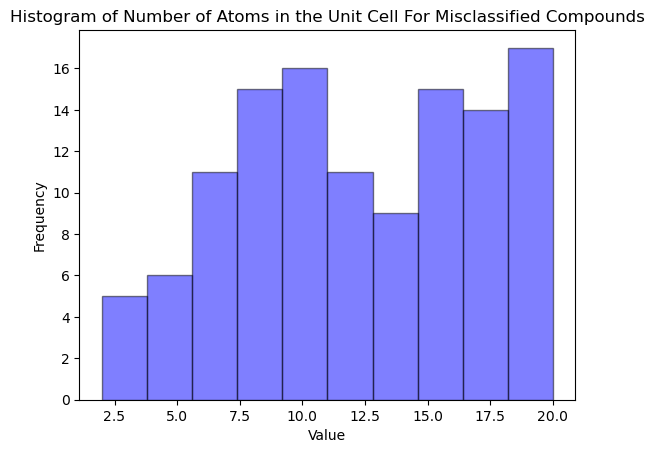

In [125]:
#first, let's get the number of elements in each of the crystals
num_elements = [len(ast.literal_eval(alist)) for alist in df_misclassfified['atomic_numbers']]

# Create a histogram
plt.hist(num_elements, bins=10, alpha=0.5, color='blue', edgecolor='black')

# Add titles and labels
plt.title('Histogram of Number of Atoms in the Unit Cell For Misclassified Compounds')
plt.xlabel('Value')
plt.ylabel('Frequency')

# Show the plot
plt.show()


In [127]:
np.mean(num_elements)

12.394957983193278

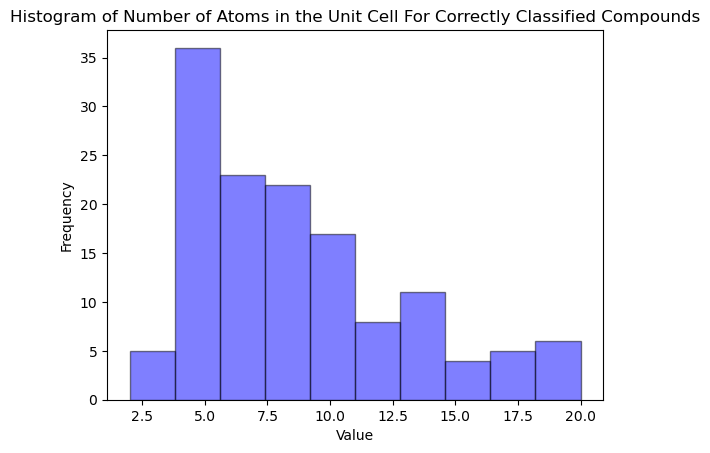

In [128]:
#first, let's get the number of elements in each of the crystals
num_elements = [len(ast.literal_eval(alist)) for alist in df_correctly_classified['atomic_numbers']]

# Create a histogram
plt.hist(num_elements, bins=10, alpha=0.5, color='blue', edgecolor='black')

# Add titles and labels
plt.title('Histogram of Number of Atoms in the Unit Cell For Correctly Classified Compounds')
plt.xlabel('Value')
plt.ylabel('Frequency')

# Show the plot
plt.show()


In [129]:
np.mean(num_elements)

8.583941605839415

Looks like the chance of getting a correct prediction drops off pretty steeply when the unit cell gets too big (though we're only limiting ourselves to 20 atom large unit cells here). I guess we could limit ourselves to compounds smaller than 10? Idk this seeems less valid than what we're doing on the alkaline earths. 

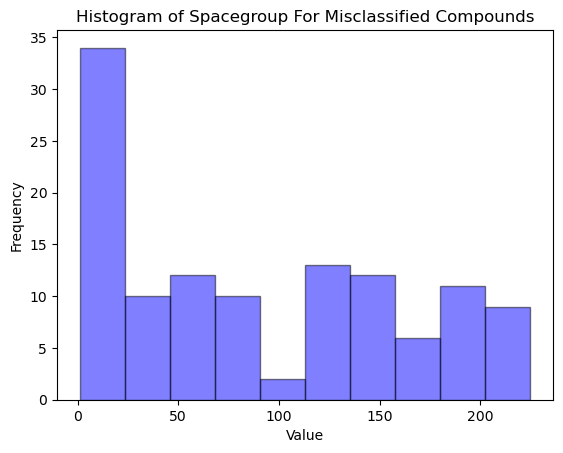

In [135]:
#first, let's get the number of elements in each of the crystals
space_groups = [float(number) for number in df_misclassfified['spacegroup.number']]

# Create a histogram
plt.hist(space_groups, bins=10, alpha=0.5, color='blue', edgecolor='black')

# Add titles and labels
plt.title('Histogram of Spacegroup For Misclassified Compounds')
plt.xlabel('Value')
plt.ylabel('Frequency')

# Show the plot
plt.show()


In [136]:
np.mean(space_groups)

91.0

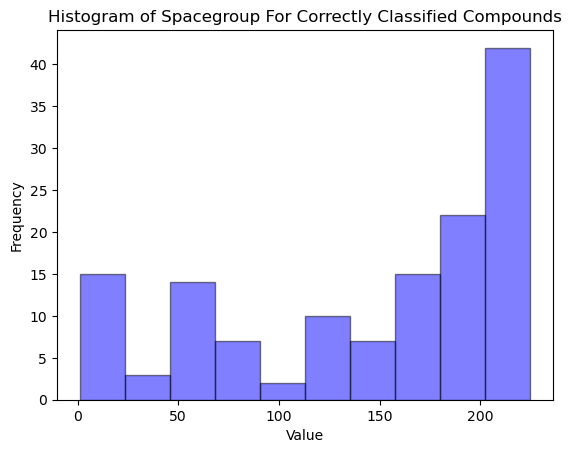

In [133]:
#first, let's get the number of elements in each of the crystals
space_groups = [float(number) for number in df_correctly_classified['spacegroup.number']]

# Create a histogram
plt.hist(space_groups, bins=10, alpha=0.5, color='blue', edgecolor='black')

# Add titles and labels
plt.title('Histogram of Spacegroup For Correctly Classified Compounds')
plt.xlabel('Value')
plt.ylabel('Frequency')

# Show the plot
plt.show()


In [134]:
np.mean(space_groups)

147.26277372262774

The space group results are awesomely interpretable! The model does better on more symmetric crystals and worse on less symmetric ones. This makes sense! 

Unfortunately, we can't just kick out the less symmetric crystals, that would be kind of ridiculous. But this was a very satisfying result

Ok, so main takeaways in terms of whether we can be more restrictive in terms of the crystals we're using is that we should probably impose some filters on atomic composition, at least for now. This is fairly straightforward in terms of restricting the test data, but requires a bit more thought in regards to applying to the training data since it will reduce the amount of training data availible, potentially by a lot. This is potentially addressable by just finding more data though. 

In addition, we need to start thinking more carefully about our train-val-test sets, especially if we start manipulating constraints and filters based on results. These initial results were done off the test set, but we may need to come back and redo on the val set to preserve the integrety of the test. In fact, we may need to re-split or get some more data for a fresh test set to avoid any kind of accidental overfitting to the test data.

Now, let's figure out why each one got misclassified to figure out how we can do better! The first way a crystal structure could fail is if it's just invalid. So let's see what percentage of the generated crystal structures were invalid. 

In [139]:
#added by Tsach
from eval_utils import (
    smact_validity, structure_validity, CompScaler, get_fp_pdist,
    load_config, load_data, get_crystals_list, prop_model_eval, compute_cov)

from collections import Counter
import argparse
import os
import json

import numpy as np
from pathlib import Path
from tqdm import tqdm
from p_tqdm import p_map
from scipy.stats import wasserstein_distance

from pymatgen.core.structure import Structure
from pymatgen.core.composition import Composition
from pymatgen.core.lattice import Lattice
from pymatgen.analysis.structure_matcher import StructureMatcher
from matminer.featurizers.site.fingerprint import CrystalNNFingerprint
from matminer.featurizers.composition.composite import ElementProperty

CrystalNNFP = CrystalNNFingerprint.from_preset("ops")
CompFP = ElementProperty.from_preset('magpie')

Percentiles = {
    'mp20': np.array([-3.17562208, -2.82196882, -2.52814761]),
    'carbon': np.array([-154.527093, -154.45865733, -154.44206825]),
    'perovskite': np.array([0.43924842, 0.61202443, 0.7364607]),
}

COV_Cutoffs = {
    'mp20': {'struc': 0.4, 'comp': 10.},
    'carbon': {'struc': 0.2, 'comp': 4.},
    'perovskite': {'struc': 0.2, 'comp': 4},
}

In [144]:
class Crystal(object):
    def __init__(self, crys_array_dict):
        self.frac_coords = crys_array_dict['frac_coords']
        self.atom_types = crys_array_dict['atom_types']
        self.lengths = crys_array_dict['lengths']
        self.angles = crys_array_dict['angles']
        self.dict = crys_array_dict

        self.get_structure()
        self.get_composition()
        self.get_validity()
        self.get_fingerprints()
    def get_structure(self):
        if min(self.lengths.tolist()) < 0:
            self.constructed = False
            self.invalid_reason = 'non_positive_lattice'
        else:
            try:
                self.structure = Structure(
                    lattice=Lattice.from_parameters(
                        *(self.lengths.tolist() + self.angles.tolist())),
                    species=self.atom_types, coords=self.frac_coords, coords_are_cartesian=False)
                self.constructed = True
            except Exception:
                self.constructed = False
                self.invalid_reason = 'construction_raises_exception'
            if self.structure.volume < 0.1:
                self.constructed = False
                self.invalid_reason = 'unrealistically_small_lattice'
    def get_composition(self):
        elem_counter = Counter(self.atom_types)
        composition = [(elem, elem_counter[elem])
                       for elem in sorted(elem_counter.keys())]
        elems, counts = list(zip(*composition))
        counts = np.array(counts)
        counts = counts / np.gcd.reduce(counts)
        self.elems = elems
        self.comps = tuple(counts.astype('int').tolist())
    def get_validity(self):
        self.comp_valid = smact_validity(self.elems, self.comps)
        if self.constructed:
            self.struct_valid = structure_validity(self.structure)
        else:
            self.struct_valid = False
        self.valid = self.comp_valid and self.struct_valid
    def get_fingerprints(self):
        elem_counter = Counter(self.atom_types)
        comp = Composition(elem_counter)
        self.comp_fp = CompFP.featurize(comp)
        try:
            site_fps = [CrystalNNFP.featurize(
                self.structure, i) for i in range(len(self.structure))]
        except Exception:
            # counts crystal as invalid if fingerprint cannot be constructed.
            print('oops')
            self.valid = False
            self.comp_fp = None
            self.struct_fp = None
            return
        self.struct_fp = np.array(site_fps).mean(axis=0)

In [146]:
def get_file_paths(root_path, task, label='', suffix='pt'):
    if label == '':
        out_name = f'eval_{task}.{suffix}'
    else:
        out_name = f'eval_{task}_{label}.{suffix}'
    out_name = os.path.join(root_path, out_name)
    return out_name


In [147]:
def get_crystal_array_list(file_path, batch_idx=0):
    data = load_data(file_path)
    crys_array_list = get_crystals_list(
        data['frac_coords'][batch_idx],
        data['atom_types'][batch_idx],
        data['lengths'][batch_idx],
        data['angles'][batch_idx],
        data['num_atoms'][batch_idx])

    if 'input_data_batch' in data:
        batch = data['input_data_batch']
        if isinstance(batch, dict):
            true_crystal_array_list = get_crystals_list(
                batch['frac_coords'], batch['atom_types'], batch['lengths'],
                batch['angles'], batch['num_atoms'])
        else:
            true_crystal_array_list = get_crystals_list(
                batch.frac_coords, batch.atom_types, batch.lengths,
                batch.angles, batch.num_atoms)
    else:
        true_crystal_array_list = None

    return crys_array_list, true_crystal_array_list

In [198]:
recon_file_path = get_file_paths('/home/gridsan/tmackey/hydra/singlerun/2023-11-08/dropout_input_layer_mp_20/', 'recon',"")

# def get_crystal_array_list(file_path, batch_idx=0):
file_path = recon_file_path

crys_array_list, true_crystal_array_list = get_crystal_array_list(file_path, batch_idx=0)

In [195]:
# Add a new column for the comparison result in the subset
indices = list(df_subset['correctly_classified'] == False)
int_indices = [i for i, x in enumerate(indices) if x]

In [199]:
#we only want the misclassified ones 
crys_array_list = [crys_array_list[indice] for indice in int_indices]

In [201]:
pred_crys = []
counter = 0 
for x in crys_array_list: 
    pred_crys.append(Crystal(x))

In [211]:
pred_crys[2].structure

Structure Summary
Lattice
    abc : 3.285897970199584 6.386678695678712 6.777977466583252
 angles : 112.03535461425781 96.25308227539062 90.2225341796875
 volume : 130.91290482620786
      A : 3.2663484551566206 0.0 -0.35790115962051017
      B : -0.28750502555451174 5.913162653108792 -2.396145458856084
      C : 0.0 0.0 6.777977466583252
    pbc : True True True
PeriodicSite: Na (0.7929, 3.347, -0.1842) [0.2926, 0.5661, 0.1884]
PeriodicSite: Ti (0.907, 0.371, 4.364) [0.2832, 0.06274, 0.6811]
PeriodicSite: V (2.403, 3.291, 2.995) [0.7847, 0.5566, 0.6801]
PeriodicSite: S (2.583, 1.888, 4.957) [0.8188, 0.3192, 0.8874]
PeriodicSite: S (0.7163, 1.695, 2.388) [0.2445, 0.2866, 0.4665]
PeriodicSite: S (0.8616, 4.885, 3.988) [0.3365, 0.8261, 0.8982]
PeriodicSite: S (2.283, 4.711, 1.104) [0.7691, 0.7968, 0.4851]

In [202]:
true_crystal_array_list = [true_crystal_array_list[indice] for indice in int_indices]
gt_crys = []
counter = 0 

for x in true_crystal_array_list: 
    gt_crys.append(Crystal(x))

In [204]:
len(gt_crys)

119

In [205]:
#first thing to look into: how many of the predictions are actually valid
list_of_results = []
for crystal in pred_crys: 
    list_of_results.append(crystal.valid)

In [206]:
np.mean(list_of_results)

0.8067226890756303

Ok, so apparently only 80% are valid. This is a little sus given previous experience, but we did feed it the stoich so that probably helped a lot. That means that the difference must be in the structure

In [214]:
class RecEval(object):

    def __init__(self, pred_crys, gt_crys, stol=0.5, angle_tol=10, ltol=0.3): #original values of stol=0.5, angle_tol=10, ltol=0.3
        assert len(pred_crys) == len(gt_crys)
        self.matcher = StructureMatcher(
            stol=stol, angle_tol=angle_tol, ltol=ltol)
        self.preds = pred_crys
        self.gts = gt_crys

    def get_match_rate_and_rms(self):
        def process_one(pred, gt, is_valid):
            if not is_valid:
                return None
            try:
                rms_dist = self.matcher.get_rms_dist(
                    pred.structure, gt.structure)
                rms_dist = None if rms_dist is None else rms_dist[0]
                if rms_dist is None: 
                    print(pred.structure)
                    print(gt.structure)
                return rms_dist
            except Exception:
                return None
        #define a function that gets the diffraction patterns for pred and gt and returns the RMSD between them
        def process_diff_pattern(pred, gt, is_valid):
            if not is_valid:
                return None
            try:
                #get the structures
                pred_structure = pred.structure
                gt_structure = gt.structure
                pred_pattern = xrd_calculator.get_pattern(pred_structure)
                gt_pattern = xrd_calculator.get_pattern(gt_structure)

                pred_adjusted_vector = np.zeros(256)
                minimum = min(256, len(pred_pattern.x))
                pred_adjusted_vector[:minimum] = pred_pattern.x[:minimum]

                gt_adjusted_vector = np.zeros(256)
                minimum = min(256, len(gt_pattern.x))
                gt_adjusted_vector[:minimum] = gt_pattern.x[:minimum]
                
                #calculate the RMSD between the two patterns
                print(pred_adjusted_vector)
                print(gt_adjusted_vector)
                rms_dist = np.sqrt(np.mean((pred_adjusted_vector - gt_adjusted_vector)**2))

                return rms_dist
            except Exception:
                return None    

        validity = [c.valid for c in self.preds]
        
        print(validity)

        rms_dists = []
        evaluate_diff_pattern = False
        if evaluate_diff_pattern:
            diff_dists = []
        for i in tqdm(range(len(self.preds))):
            rms_dists.append(process_one(
                self.preds[i], self.gts[i], validity[i]))
            if evaluate_diff_pattern:
                diff_dists.append(process_diff_pattern(self.preds[i], self.gts[i], validity[i]))
        rms_dists = np.array(rms_dists)
        if evaluate_diff_pattern:
            diff_dists = np.array(diff_dists)
            average_diff_dist = diff_dists[diff_dists != None].mean()
            #print out all the diff dists
        else:
            average_diff_dist = None
        match_rate = sum(rms_dists != None) / len(self.preds)
        mean_rms_dist = rms_dists[rms_dists != None].mean()

        return {'match_rate': match_rate,
                'rms_dist': mean_rms_dist,
                'diff_dist': average_diff_dist,
                'rmsd_values': rms_dists}

    def get_metrics(self):
        return self.get_match_rate_and_rms()

In [215]:
rec_evaluator = RecEval(pred_crys, gt_crys)
recon_metrics = rec_evaluator.get_metrics()

[True, True, True, True, True, True, True, True, False, True, True, True, True, True, True, True, True, True, True, True, True, True, False, True, False, True, True, False, True, False, True, True, True, True, True, True, True, True, True, False, True, True, True, True, True, True, False, False, True, False, True, True, True, True, True, True, True, False, False, False, True, True, True, True, True, True, False, True, True, True, False, True, True, True, True, False, False, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, False, True, True, True, True, True, True, True, True, True, False, False, True, False, True, True, False, False, False, True, True, True, True, True, True, True, True]


 11%|█         | 13/119 [00:00<00:00, 109.73it/s]

Full Formula (Ga4 Te4)
Reduced Formula: GaTe
abc   :   4.270289   4.328177  14.716544
angles:  88.980713  90.253006  91.189255
pbc   :       True       True       True
Sites (8)
  #  SP           a         b         c
---  ----  --------  --------  --------
  0  Ga    0.814028  0.355547  0.627193
  1  Ga    0.316187  0.846424  0.379747
  2  Ga    0.306003  0.858792  0.877039
  3  Ga    0.808737  0.352355  0.12672
  4  Te    0.810521  0.858584  0.504079
  5  Te    0.804625  0.852901  0.002219
  6  Te    0.30636   0.355611  0.751888
  7  Te    0.312169  0.352835  0.253019
Full Formula (Ga4 Te4)
Reduced Formula: GaTe
abc   :   4.134600   4.134600  18.425570
angles:  90.000000  90.000000 120.000008
pbc   :       True       True       True
Sites (8)
  #  SP           a         b         c
---  ----  --------  --------  --------
  0  Ga    0.666667  0.333333  0.817041
  1  Ga    0.333333  0.666667  0.317041
  2  Ga    0.333333  0.666667  0.182959
  3  Ga    0.666667  0.333333  0.682959
  4  

 29%|██▉       | 35/119 [00:00<00:00, 100.65it/s]

Full Formula (Eu4 Al8 Ge4)
Reduced Formula: EuAl2Ge
abc   :   4.405741   6.938111  14.345037
angles:  95.755615  98.445580  88.885262
pbc   :       True       True       True
Sites (16)
  #  SP           a         b         c
---  ----  --------  --------  --------
  0  Eu    0.300547  0.613715  0.735081
  1  Eu    0.432008  0.280878  0.990198
  2  Eu    0.540234  0.815382  0.178487
  3  Eu    0.144064  0.536835  0.432045
  4  Al    0.895729  0.632575  0.942634
  5  Al    0.039853  0.212418  0.200171
  6  Al    0.198526  0.063147  0.522701
  7  Al    0.846332  0.961959  0.837888
  8  Al    0.743163  0.876071  0.612783
  9  Al    0.630239  0.144147  0.384105
 10  Al    0.730791  0.298225  0.597552
 11  Al    0.290755  0.114667  0.721736
 12  Ge    0.122525  0.941548  0.333656
 13  Ge    0.396814  0.829388  0.953707
 14  Ge    0.842     0.328009  0.810872
 15  Ge    0.560665  0.403339  0.253367
Full Formula (Eu4 Al8 Ge4)
Reduced Formula: EuAl2Ge
abc   :   4.283127   7.246503  11.243032
a

...

Full Formula (Si2 C4 N8)
Reduced Formula: Si(CN2)2
abc   :   5.096716   5.802810   6.510518
angles:  87.484657  81.213638  87.906715
pbc   :       True       True       True
Sites (14)
  #  SP           a         b         c
---  ----  --------  --------  --------
  0  Si    0.40938   0.121128  0.216266
  1  Si    0.806296  0.436847  0.635216
  2  C     0.242968  0.525548  0.75965
  3  C     0.130588  0.500231  0.303062
  4  C     0.093773  0.065992  0.554814
  5  C     0.973057  0.037142  0.082972
  6  N     0.904771  0.552061  0.391768
  7  N     0.994635  0.554185  0.803817
  8  N     0.306167  0.004405  0.467303
  9  N     0.221845  0.010538  0.041205
 10  N     0.344986  0.424004  0.221337
 11  N     0.863738  0.147132  0.630864
 12  N     0.48284   0.49577   0.721085
 13  N     0.733112  0.045969  0.14185
Full Formula (Si2 C4 N8)
Reduced Formula: Si(CN2)2
abc   :   6.684378   6.684378   6.684378
angles:  90.000000  90.000000  90.000000
pbc   :       True       True       True
Sit

 92%|█████████▏| 109/119 [00:01<00:00, 118.19it/s]

Full Formula (Sr1 Eu1 Co2 O6)
Reduced Formula: SrEu(CoO3)2
abc   :   3.697403   3.734561  10.374268
angles:  86.908455  87.235947  82.775261
pbc   :       True       True       True
Sites (10)
  #  SP           a         b         c
---  ----  --------  --------  --------
  0  Sr    0.619703  0.037884  0.260768
  1  Eu    0.55529   0.904939  0.727537
  2  Co    0.048862  0.395092  0.945343
  3  Co    0.105336  0.374982  0.494511
  4  O     0.100133  0.56168   0.645658
  5  O     0.136626  0.601253  0.342147
  6  O     0.05453   0.332758  0.111425
  7  O     0.048832  0.907539  0.881896
  8  O     0.639355  0.176355  0.499591
  9  O     0.563712  0.394269  0.876602
Full Formula (Sr1 Eu1 Co2 O6)
Reduced Formula: SrEu(CoO3)2
abc   :   3.788584   3.788584   7.676178
angles:  90.000000  90.000000  90.000000
pbc   :       True       True       True
Sites (10)
  #  SP      a    b         c
---  ----  ---  ---  --------
  0  Sr    0    0    0.5
  1  Eu    0    0    0
  2  Co    0.5  0.5  0.252

100%|██████████| 119/119 [00:01<00:00, 113.50it/s]

Full Formula (H4 Pb4 Cl4 O4)
Reduced Formula: HPbClO
abc   :   3.914639   6.423855  10.501866
angles:  89.824303  90.220886  90.349335
pbc   :       True       True       True
Sites (16)
  #  SP           a         b         c
---  ----  --------  --------  --------
  0  H     0.288741  0.341824  0.027699
  1  H     0.794185  0.549794  0.248085
  2  H     0.785362  0.117592  0.247091
  3  H     0.280236  0.160716  0.753974
  4  Pb    0.79169   0.026746  0.992813
  5  Pb    0.282291  0.77477   0.294578
  6  Pb    0.789598  0.22649   0.564594
  7  Pb    0.297782  0.754783  0.732587
  8  Cl    0.295316  0.281332  0.355321
  9  Cl    0.287506  0.680119  0.040423
 10  Cl    0.78923   0.406565  0.799928
 11  Cl    0.784193  0.790709  0.502496
 12  O     0.790964  0.919553  0.815934
 13  O     0.289797  0.187168  0.009161
 14  O     0.780724  0.97366   0.207471
 15  O     0.283806  0.107172  0.664469
Full Formula (H4 Pb4 Cl4 O4)
Reduced Formula: HPbClO
abc   :   4.069687   7.185355   9.957517

In [209]:
recon_metrics

{'match_rate': 0.13445378151260504,
 'rms_dist': 0.09438773780407993,
 'diff_dist': None,
 'rmsd_values': array([None, None, None, None, None, 0.32461618937675685, None, None,
        None, None, None, None, 0.03113012244576284, None, None, None,
        0.029466852081423783, None, None, None, None, None, None, None,
        None, None, None, None, None, None, None, 0.010359323160226478,
        None, None, None, None, None, None, None, None, None,
        0.17127295872589407, None, None, None, None, None, None, None,
        None, None, None, 0.01399317643063499, None, None, None, None,
        None, None, None, None, 0.045470572418107466, 0.009091251777578016,
        0.41130352571349504, None, None, None, None, None, None, None,
        None, None, None, None, None, None, None, None, None, None,
        0.013252947601903983, 0.02367450236321188, None, None, None, None,
        None, None, None, 0.010350051406569713, None, None, None, None,
        0.041141999299418655, None, None, 0

From this analysis, I think it's now abundantly clear that the biggest limitation of the stoich-informed dropout model is the inability to predict low-symmetry groups (very understandable tbh) and the more we can push it towards that goal the better. It might be worth trying to implement a space-group predictor either with the native property prediction method or with an external tool that has been developed specifically for this purpose. This is a whole additional branch of optimization and experiments but it could lead to good results I think.